# Quantile Regression

**formalML — Nonparametric & Distribution-Free Track, Topic 2**

Linear quantile regression in the Koenker–Bassett 1978 framework. The check loss as
the asymmetric analog of squared loss; the estimator as a linear program;
asymptotic normality of $\hat\beta(\tau)$; the crossing pathology and its
rearrangement fix; penalized variants for high dimensions; and the role of QR as
the base learner inside Conformalized Quantile Regression (Topic 1, §6).

## Setup

In [5]:
# Core dependencies
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import linprog

from sklearn.linear_model import QuantileRegressor, LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Plot style (matches formalML site theme — same palette as conformal-prediction)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'figure.figsize': (12, 5),
    'figure.dpi': 110,
    'font.size': 11,
    'font.family': 'serif',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BLUE = '#2563EB'
RED = '#DC2626'
GREEN = '#059669'
AMBER = '#D97706'
PURPLE = '#7C3AED'
SLATE = '#475569'
TEAL = '#0F6E56'
LIGHT_BLUE = '#DBEAFE'
LIGHT_RED = '#FEE2E2'
LIGHT_GREEN = '#D1FAE5'
LIGHT_AMBER = '#FEF3C7'
LIGHT_PURPLE = '#EDE9FE'
LIGHT_SLATE = '#F1F5F9'

# Reproducibility
rng = np.random.default_rng(42)

# Output directory for figures (notebook expects this to exist alongside it)
import os
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)


# Synthetic data generator — same shape as the conformal-prediction notebook so
# numerical results are comparable across topics in the T4 track.
#
# DGP:  X ~ Uniform(-2, 2)
#       sigma(x) = 0.3 + 0.6 * |x|
#       Y = 0.5 * x + sin(1.5 * x) + sigma(x) * epsilon,   epsilon ~ N(0, 1)
#
# The mean function is m(x) = 0.5x + sin(1.5x) and the noise scale grows with
# |x|. The conditional quantile is therefore available in closed form,
#
#       xi_tau(Y | X = x) = 0.5x + sin(1.5x) + (0.3 + 0.6|x|) * Phi^{-1}(tau),
#
# which we use as the ground truth in numerical verification cells throughout.
def synth_heteroscedastic(n, rng):
    x = rng.uniform(-2, 2, n)
    sigma = 0.3 + 0.6 * np.abs(x)
    y = 0.5 * x + np.sin(1.5 * x) + rng.normal(0, sigma)
    return x, y


def true_conditional_quantile(x, tau):
    """Closed-form conditional quantile under the DGP above."""
    return 0.5 * x + np.sin(1.5 * x) + (0.3 + 0.6 * np.abs(x)) * norm.ppf(tau)


print('Setup complete. NumPy', np.__version__, 'matplotlib', plt.matplotlib.__version__)
print('SciPy', __import__('scipy').__version__, 'sklearn', __import__('sklearn').__version__)


Setup complete. NumPy 2.4.4 matplotlib 3.10.9
SciPy 1.17.1 sklearn 1.8.0


---

Empirical vs theoretical quantile at n = 20,000:
   tau |  Phi^-1(tau) |  argmin emp loss |     diff
--------------------------------------------------------
  0.10 |      -1.2816 |          -1.2700 |  +0.0116
  0.25 |      -0.6745 |          -0.6700 |  +0.0045
  0.50 |       0.0000 |           0.0100 |  +0.0100
  0.75 |       0.6745 |           0.6800 |  +0.0055
  0.90 |       1.2816 |           1.2900 |  +0.0084

Gradient check at q = Phi^-1(0.5) = 0:  F_n(q) - 0.5 = -0.0051
(should be small for moderate n; exact zero at the population minimum.)


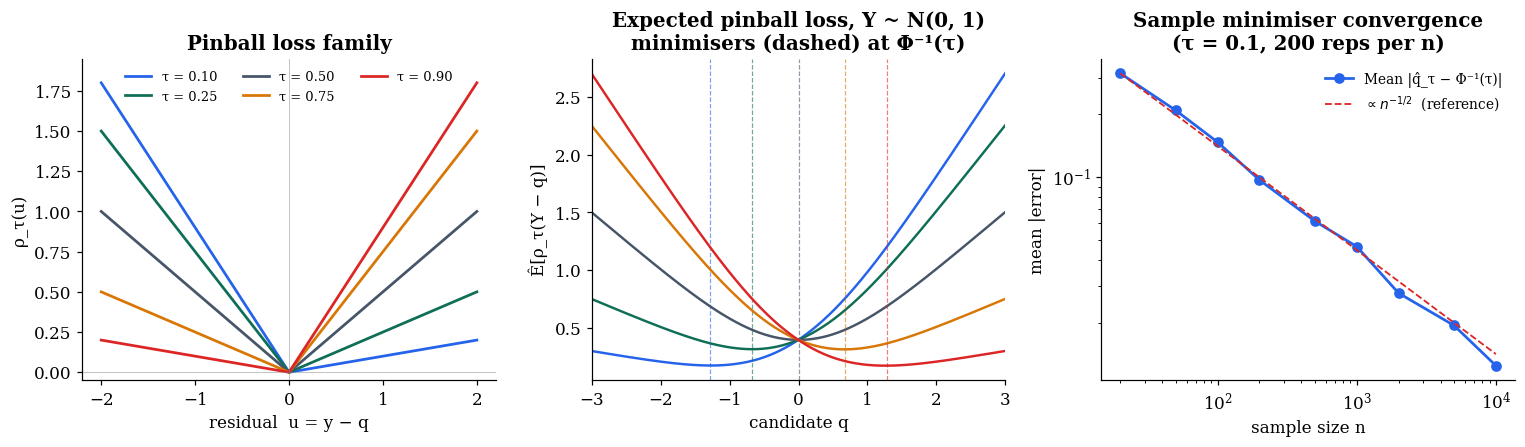


Saved: figures/qr_pinball_loss.png


In [6]:
# === The Pinball Loss & The Population Quantile ===
# Quantile regression rests on a single asymmetric loss function, the "check" or
# "pinball" loss. Where squared loss penalises positive and negative residuals
# symmetrically and recovers the conditional MEAN at its minimum, the pinball
# loss penalises them asymmetrically and recovers the conditional QUANTILE.
# This cell makes that statement precise.
#
# ──────────────────────────────────────────────────────────────────────────
# Definition 1 (Pinball loss).
# For tau in (0, 1) and any real residual u, the pinball loss at level tau is
#
#     rho_tau(u) = u * (tau - 1{u < 0})
#                = max{ tau * u,  (tau - 1) * u }.
#
# Equivalently, rho_tau(u) is a piecewise-linear V with slope tau on the right
# half-line and slope (tau - 1) on the left.  At tau = 0.5, rho_0.5(u) = 0.5 |u|
# is half the absolute loss; for tau != 0.5, the V is asymmetric, with the
# steeper side on whichever direction we pay more for getting wrong.
# ──────────────────────────────────────────────────────────────────────────
#
# ──────────────────────────────────────────────────────────────────────────
# Theorem 1 (Pinball minimisation recovers the population quantile).
# Let Y be a real random variable with cumulative distribution function F and
# finite mean. For each tau in (0, 1), the (any) tau-quantile
#
#     xi_tau = inf{ q in R : F(q) >= tau }
#
# minimises the expected pinball loss:
#
#     xi_tau in argmin_{q in R}  E[ rho_tau(Y - q) ].
# ──────────────────────────────────────────────────────────────────────────
#
# PROOF. Write the expected loss as a function of q,
#
#     L(q) = E[ rho_tau(Y - q) ]
#          = tau * integral_q^infty (y - q) dF(y)
#            + (1 - tau) * integral_{-infty}^q (q - y) dF(y).
#
# The first term penalises Y > q at rate tau (the "right side"); the second
# penalises Y < q at rate (1 - tau) (the "left side"). Differentiate L(q) under
# the integral. The derivative of the first term with respect to q is
# -tau * (1 - F(q)) (the Leibniz rule contribution from the lower limit, plus
# the constant -tau under the integrand). The derivative of the second term is
# (1 - tau) * F(q) (matching contribution from the upper limit and integrand).
# Adding,
#
#     L'(q) = -tau * (1 - F(q)) + (1 - tau) * F(q)  =  F(q) - tau.
#
# Setting L'(q) = 0 gives F(q) = tau, i.e., q = xi_tau. The second derivative,
# wherever F is differentiable, is L''(q) = f(q) >= 0, so L is convex; whenever
# the conditional density f at xi_tau is strictly positive, the minimiser is
# unique. (When F is flat at xi_tau, the argmin set is an interval; we take the
# smallest minimiser by convention.)                                        []
#
# REMARK 1. The proof opens no black boxes — it does not require Y to have a
# density, finite variance, or bounded support. The piecewise-linear structure
# of rho_tau is doing all of the work: differentiating it produces the
# indicator (1{u < 0}), and the indicator's expectation is exactly F.
#
# REMARK 2. The same calculation, conditioned on X = x, gives the conditional
# quantile xi_tau(Y | X = x). This is what quantile regression estimates: the
# argmin over functions q(x) of E[ rho_tau(Y - q(X)) ] is the conditional
# tau-quantile function of Y given X, almost surely. The QR estimator
# replaces the population expectation with the empirical mean and the function
# class with a parametric one (the linear span of the features).

# Verify Theorem 1 numerically. Sample Y ~ N(0, 1) and minimise the empirical
# pinball loss over a fine grid of q for several tau. The minimisers should
# approach Phi^{-1}(tau) as n grows.
np.random.seed(0)
y_sample_large = norm.rvs(size=20_000, random_state=1)
q_grid = np.linspace(-3, 3, 601)
taus_to_check = [0.10, 0.25, 0.50, 0.75, 0.90]

print('Empirical vs theoretical quantile at n = 20,000:')
print(f'{"tau":>6} | {"Phi^-1(tau)":>12} | {"argmin emp loss":>16} | {"diff":>8}')
print('-' * 56)
for tau in taus_to_check:
    L_grid = np.array([
        np.mean(np.where(y_sample_large >= q,
                         tau * (y_sample_large - q),
                         (tau - 1) * (y_sample_large - q)))
        for q in q_grid
    ])
    q_hat = q_grid[L_grid.argmin()]
    q_true = norm.ppf(tau)
    print(f'{tau:>6.2f} | {q_true:>12.4f} | {q_hat:>16.4f} | {q_hat - q_true:>+8.4f}')

# Also verify the gradient identity F(q) - tau = 0 numerically.
F_at_qhat = np.mean(y_sample_large <= norm.ppf(0.5))
print(f'\nGradient check at q = Phi^-1(0.5) = 0:  F_n(q) - 0.5 = {F_at_qhat - 0.5:+.4f}')
print('(should be small for moderate n; exact zero at the population minimum.)')

# ─── Figure 1: Pinball loss family + population minimisation + sample
# convergence ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Panel A — pinball-loss curves at varying tau
u_axis = np.linspace(-2, 2, 401)
tau_panel = [0.10, 0.25, 0.50, 0.75, 0.90]
panel_colors = [BLUE, TEAL, SLATE, AMBER, RED]
ax = axes[0]
for tau, c in zip(tau_panel, panel_colors):
    rho = np.where(u_axis >= 0, tau * u_axis, (tau - 1) * u_axis)
    ax.plot(u_axis, rho, color=c, lw=1.8, label=f'τ = {tau:.2f}')
ax.axvline(0, color='gray', lw=0.6, alpha=0.5)
ax.axhline(0, color='gray', lw=0.6, alpha=0.5)
ax.set_xlabel('residual  u = y − q')
ax.set_ylabel('ρ_τ(u)')
ax.set_title('Pinball loss family')
ax.legend(loc='upper center', frameon=False, ncol=3, fontsize=8.5)
ax.set_ylim(-0.05, 1.95)

# Panel B — expected pinball loss as a function of q for Y ~ N(0,1)
ax = axes[1]
y_pop = norm.rvs(size=50_000, random_state=7)  # large sample as proxy for E[]
for tau, c in zip(tau_panel, panel_colors):
    L_q = np.array([
        np.mean(np.where(y_pop >= q, tau * (y_pop - q), (tau - 1) * (y_pop - q)))
        for q in q_grid
    ])
    ax.plot(q_grid, L_q, color=c, lw=1.6, label=f'τ = {tau:.2f}')
    ax.axvline(norm.ppf(tau), color=c, lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('candidate q')
ax.set_ylabel('Ê[ρ_τ(Y − q)]')
ax.set_title('Expected pinball loss, Y ~ N(0, 1)\nminimisers (dashed) at Φ⁻¹(τ)')
ax.set_xlim(-3, 3)

# Panel C — sample minimiser convergence to xi_tau
ax = axes[2]
n_grid = np.array([20, 50, 100, 200, 500, 1000, 2000, 5000, 10_000])
tau_track = 0.10
true_q = norm.ppf(tau_track)
n_reps = 200
abs_errors = []
for n in n_grid:
    errs = []
    for r in range(n_reps):
        ys = norm.rvs(size=n, random_state=1000 * r + n)
        L_grid_n = np.array([
            np.mean(np.where(ys >= q, tau_track * (ys - q), (tau_track - 1) * (ys - q)))
            for q in q_grid
        ])
        errs.append(abs(q_grid[L_grid_n.argmin()] - true_q))
    abs_errors.append(np.mean(errs))
abs_errors = np.array(abs_errors)
ax.plot(n_grid, abs_errors, 'o-', color=BLUE, lw=1.8, ms=6, label='Mean |q̂_τ − Φ⁻¹(τ)|')
# Asymptotic rate: 1/sqrt(n) reference (KB78 / standard quantile-CLT scaling)
ref_rate = abs_errors[0] * np.sqrt(n_grid[0]) / np.sqrt(n_grid)
ax.plot(n_grid, ref_rate, '--', color=RED, lw=1.2, label=r'$\propto n^{-1/2}$  (reference)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('sample size n')
ax.set_ylabel('mean |error|')
ax.set_title(f'Sample minimiser convergence\n(τ = {tau_track}, 200 reps per n)')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/qr_pinball_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {FIG_DIR}/qr_pinball_loss.png')


---

At the QR optimum, fraction of negative residuals should ≈ tau:
  tau = 0.10:  P(Y < q̂(X)) = 0.098
  tau = 0.50:  P(Y < q̂(X)) = 0.500
  tau = 0.90:  P(Y < q̂(X)) = 0.898
(This is the sample analog of L'(q) = F(q) - tau = 0 — the KKT/first-order condition of QR at the population level.)


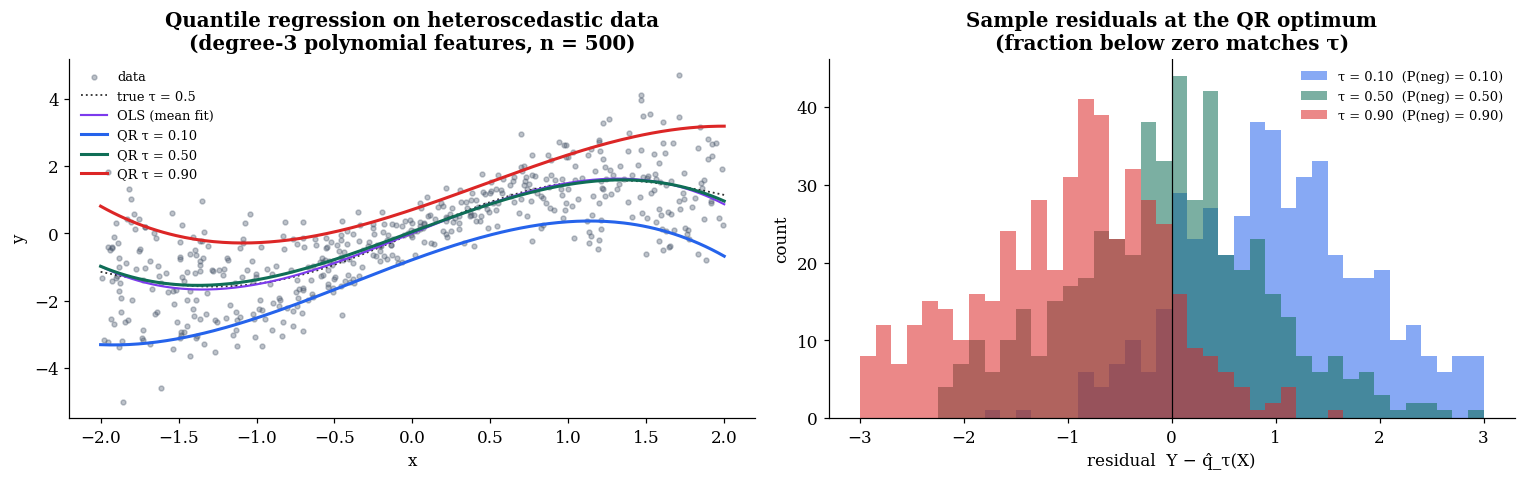


Saved: figures/qr_linear_fit.png


In [7]:
# === Linear Quantile Regression ===
# Theorem 1 says the population tau-quantile of Y is recovered by minimising the
# expected pinball loss. The Koenker-Bassett 1978 quantile regression estimator
# is the empirical-version twin of that statement: minimise the SAMPLE pinball
# loss over a parametric family of conditional-quantile candidates.
#
# ──────────────────────────────────────────────────────────────────────────
# Definition 2 (Linear quantile regression estimator).
# Given features (X_i in R^p) and responses (Y_i in R) for i = 1, ..., n, the
# linear quantile regression estimator at level tau in (0, 1) is
#
#     beta-hat(tau) = argmin_{beta in R^p}  sum_{i=1}^{n} rho_tau(Y_i - X_i^T beta).
#
# The fitted conditional quantile at a new point x is q-hat_tau(x) = x^T beta-hat(tau).
# When the feature vector includes a constant (intercept), the model is
#     Y_i  =  X_i^T beta(tau)  +  e_i,   with   xi_tau(e_i | X_i) = 0.
# ──────────────────────────────────────────────────────────────────────────
#
# REMARK 3 (When does linear QR target the right thing?).
# If Y = X^T beta_0 + epsilon with epsilon independent of X and xi_tau(epsilon) = c_tau,
# then xi_tau(Y | X = x) = x^T beta_0 + c_tau. Linear QR with an intercept
# recovers (beta_0, c_tau) exactly in the population. Under heteroscedastic
# noise — say Y = X^T beta_0 + sigma(X) * epsilon — the conditional quantile
#     xi_tau(Y | X = x) = x^T beta_0 + sigma(x) * c_tau
# is NOT linear in x unless sigma is. The fix is to enrich the feature map
# (polynomial, spline, RBF) so the linear span includes the conditional
# quantile function. That's the path we take throughout: degree-3 polynomial
# features applied to a univariate covariate.
#
# REMARK 4 (Why an intercept matters).
# Without an intercept, the line is forced through the origin, and the QR
# estimator can pick up bias to compensate; with an intercept, the estimator
# decomposes cleanly into a slope (the location) and an intercept that absorbs
# the noise quantile c_tau. Standard practice — and what every implementation
# we use here does — is to include an intercept either as a separate feature
# column or as the bias term of an LP solver.
#
# Helper: the workhorse fit_predict_quantile used throughout this notebook.
# Same shape as the conformal-prediction notebook (sklearn QuantileRegressor
# on PolynomialFeatures(degree=3, include_bias=False) with a small L2 ridge).
def fit_predict_quantile(x_train, y_train, x_eval, tau, alpha_l2=0.01, degree=3):
    """Quantile regression at level tau on degree-`degree` polynomial features.

    x_train, y_train: 1D arrays.
    x_eval:           1D array of points at which to predict the conditional tau-quantile.
    alpha_l2:         small L2 penalty for numerical stability (kept tiny so KB78
                      asymptotics are not distorted).
    Returns: 1D array of fitted conditional-quantile predictions on x_eval.
    """
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Phi_train = poly.fit_transform(np.asarray(x_train).reshape(-1, 1))
    Phi_eval = poly.transform(np.asarray(x_eval).reshape(-1, 1))
    qr = QuantileRegressor(quantile=tau, alpha=alpha_l2, solver='highs')
    qr.fit(Phi_train, y_train)
    return qr.predict(Phi_eval)


# Demonstration: heteroscedastic data, three QR fits at tau in {0.1, 0.5, 0.9},
# plus OLS for contrast.
rng_demo = np.random.default_rng(11)
n_demo = 500
x_demo, y_demo = synth_heteroscedastic(n_demo, rng_demo)
x_grid = np.linspace(-2, 2, 200)

q10 = fit_predict_quantile(x_demo, y_demo, x_grid, 0.10)
q50 = fit_predict_quantile(x_demo, y_demo, x_grid, 0.50)
q90 = fit_predict_quantile(x_demo, y_demo, x_grid, 0.90)

ols = LinearRegression().fit(
    PolynomialFeatures(degree=3, include_bias=False).fit_transform(x_demo.reshape(-1, 1)),
    y_demo,
)
ols_pred = ols.predict(
    PolynomialFeatures(degree=3, include_bias=False).fit_transform(x_grid.reshape(-1, 1))
)

# Truth (from closed form)
true_10 = true_conditional_quantile(x_grid, 0.10)
true_50 = true_conditional_quantile(x_grid, 0.50)
true_90 = true_conditional_quantile(x_grid, 0.90)

# Empirical residual sign rate at the QR optimum: at tau, roughly tau fraction
# of training residuals should be negative (Y_i below fit) and 1 - tau positive.
def fitted_at_train(tau):
    return fit_predict_quantile(x_demo, y_demo, x_demo, tau)

resid_10 = y_demo - fitted_at_train(0.10)
resid_50 = y_demo - fitted_at_train(0.50)
resid_90 = y_demo - fitted_at_train(0.90)

print('At the QR optimum, fraction of negative residuals should ≈ tau:')
print(f'  tau = 0.10:  P(Y < q̂(X)) = {(resid_10 < 0).mean():.3f}')
print(f'  tau = 0.50:  P(Y < q̂(X)) = {(resid_50 < 0).mean():.3f}')
print(f'  tau = 0.90:  P(Y < q̂(X)) = {(resid_90 < 0).mean():.3f}')
print('(This is the sample analog of L\'(q) = F(q) - tau = 0 — the KKT/'
      'first-order condition of QR at the population level.)')

# ─── Figure 2: Linear QR fit on heteroscedastic data ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel A — three QR fits + OLS + truth
ax = axes[0]
ax.scatter(x_demo, y_demo, s=10, color=SLATE, alpha=0.35, label='data')
ax.plot(x_grid, true_50, color='black', lw=1.2, ls=':', alpha=0.8, label='true τ = 0.5')
ax.plot(x_grid, ols_pred, color=PURPLE, lw=1.4, label='OLS (mean fit)')
ax.plot(x_grid, q10, color=BLUE, lw=2.0, label='QR τ = 0.10')
ax.plot(x_grid, q50, color=TEAL, lw=2.0, label='QR τ = 0.50')
ax.plot(x_grid, q90, color=RED, lw=2.0, label='QR τ = 0.90')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Quantile regression on heteroscedastic data\n(degree-3 polynomial features, n = 500)')
ax.legend(loc='upper left', frameon=False, fontsize=8.5)

# Panel B — residual histograms + fraction-negative annotations
ax = axes[1]
bins = np.linspace(-3, 3, 41)
ax.hist(resid_10, bins=bins, color=BLUE, alpha=0.55, label=f'τ = 0.10  (P(neg) = {(resid_10 < 0).mean():.2f})')
ax.hist(resid_50, bins=bins, color=TEAL, alpha=0.55, label=f'τ = 0.50  (P(neg) = {(resid_50 < 0).mean():.2f})')
ax.hist(resid_90, bins=bins, color=RED, alpha=0.55, label=f'τ = 0.90  (P(neg) = {(resid_90 < 0).mean():.2f})')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('residual  Y − q̂_τ(X)')
ax.set_ylabel('count')
ax.set_title('Sample residuals at the QR optimum\n(fraction below zero matches τ)')
ax.legend(loc='upper right', frameon=False, fontsize=8.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/qr_linear_fit.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {FIG_DIR}/qr_linear_fit.png')


---

Design matrix: n = 40, p = 4 (intercept + x + x^2 + x^3)

Coefficient comparison (linprog vs sklearn):
         feature     linprog     sklearn      |diff|
  --------------------------------------------------
               1    0.036789    0.036789    3.47e-16
               x    2.084169    2.084169    7.11e-15
             x^2    0.111493    0.111493    1.42e-14
             x^3   -0.324159   -0.324159    8.16e-15

  Max coefficient |diff|: 1.42e-14  (machine precision)

Interpolated observations (|residual| < 1e-07):  4
Predicted by Remark 5: exactly p = 4.
Positive residuals (u^+ > 0):  18
Negative residuals (u^- > 0):  18
Sum should equal n - p_interp = 36.

At tau = 0.10, n = 400:
  max coefficient |diff| = 1.67e-16  (linprog vs sklearn)
  P(strictly negative residual) = 0.095  (target: ~0.10)


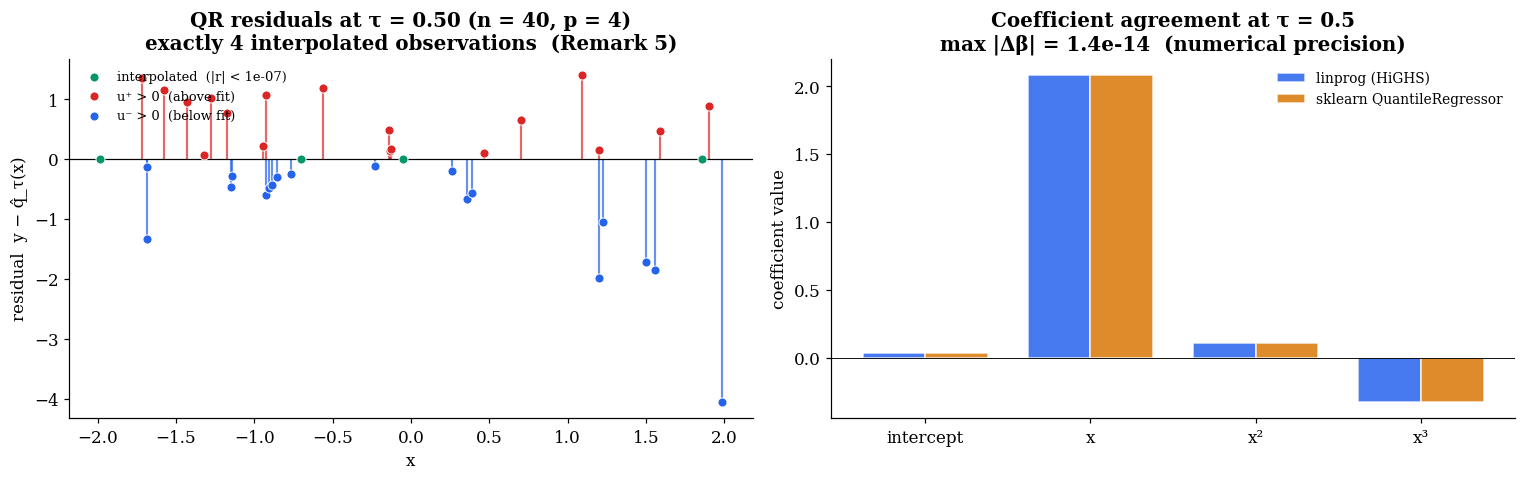


Saved: figures/qr_lp_reformulation.png


In [8]:
# === The LP Reformulation ===
# The pinball loss is piecewise-linear, so the QR optimisation is a linear
# program. This is more than a curiosity: it explains why sklearn's
# QuantileRegressor uses HiGHS (a state-of-the-art LP solver), why QR is exact
# rather than iterative, and why the "interpolation" structure of the fit is
# combinatorial — exactly p data points sit on the fitted line in the
# non-degenerate case.
#
# The trick is to split each residual r_i = y_i - x_i^T beta into its positive
# and negative parts:
#
#     r_i = u_i^+ - u_i^-,    u_i^+ = max(r_i, 0),   u_i^- = max(-r_i, 0).
#
# Then rho_tau(r_i) = tau * u_i^+ + (1 - tau) * u_i^-, which is LINEAR in the
# slack variables. Stacking the n constraints,
#
# ──────────────────────────────────────────────────────────────────────────
# Definition 3 (LP reformulation of QR).
# Quantile regression at level tau is equivalent to the linear program
#
#     min_{beta, u^+, u^-}    tau * 1^T u^+  +  (1 - tau) * 1^T u^-
#     subject to              y - X beta = u^+ - u^-
#                             u^+ >= 0,  u^- >= 0,
#                             beta in R^p (free).
#
# Stacking all variables into z = (beta, u^+, u^-) in R^{p + 2n}, this is a
# standard-form LP with cost c = (0_p, tau * 1_n, (1 - tau) * 1_n), equality
# constraint A_eq z = b_eq with A_eq = [X, -I, I] and b_eq = y, and
# nonnegativity bounds on the slacks (beta is unbounded).
# ──────────────────────────────────────────────────────────────────────────
#
# REMARK 5 (Combinatorial structure of the optimum).
# A basic feasible solution of an LP has at most as many nonzero variables as
# constraints — n here — so the optimal (beta, u^+, u^-) has at most n nonzeros
# among the 2n slacks. But each row i has exactly ONE of u_i^+, u_i^- positive
# (both being positive would violate optimality: a quick swap reduces cost).
# So each observation contributes one slack. The remaining slack-degrees go to
# beta (which is p-dimensional). Hence: at exactly p observations,
# u_i^+ = u_i^- = 0, i.e., the QR fit INTERPOLATES p of the n data points. This
# is unique to QR — OLS interpolates none in general, ridge interpolates all
# only in the limit.
#
# Build the LP for a small QR problem and solve with scipy.optimize.linprog,
# then compare to sklearn's QuantileRegressor (which calls HiGHS via the same
# LP under the hood). Coefficients must match to numerical precision.

def solve_qr_linprog(X, y, tau):
    """Solve QR via the LP reformulation using scipy.optimize.linprog (HiGHS).

    X: (n, p) design matrix (include constant column for intercept).
    y: (n,) responses.
    tau: quantile level in (0, 1).
    Returns: (beta, residuals, slack_pos, slack_neg).
    """
    n, p = X.shape
    # z = [beta (p), u_pos (n), u_neg (n)],  total p + 2n variables.
    c = np.concatenate([np.zeros(p), tau * np.ones(n), (1 - tau) * np.ones(n)])
    # Equality constraint: y - X beta = u_pos - u_neg
    # i.e.  X beta + u_pos - u_neg = y    (move y to RHS)
    A_eq = np.hstack([X, np.eye(n), -np.eye(n)])
    b_eq = y
    # Bounds: beta unbounded, slacks >= 0
    bounds = [(None, None)] * p + [(0, None)] * (2 * n)
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    if not res.success:
        raise RuntimeError(f'LP failed: {res.message}')
    z = res.x
    beta = z[:p]
    u_pos = z[p:p + n]
    u_neg = z[p + n:]
    return beta, y - X @ beta, u_pos, u_neg


# Set up a small QR problem (degree-3 polynomial features → p = 4 with intercept)
rng_lp = np.random.default_rng(2024)
n_lp = 40
x_lp, y_lp = synth_heteroscedastic(n_lp, rng_lp)
poly = PolynomialFeatures(degree=3, include_bias=True)  # include intercept
X_lp = poly.fit_transform(x_lp.reshape(-1, 1))
p_lp = X_lp.shape[1]
print(f'Design matrix: n = {n_lp}, p = {p_lp} (intercept + x + x^2 + x^3)')

# Solve via linprog
tau_lp = 0.5
beta_lp, resid_lp, u_pos_lp, u_neg_lp = solve_qr_linprog(X_lp, y_lp, tau_lp)

# Solve via sklearn (which uses HiGHS internally via the same LP)
poly_no_bias = PolynomialFeatures(degree=3, include_bias=False)
X_sk = poly_no_bias.fit_transform(x_lp.reshape(-1, 1))
qr_sk = QuantileRegressor(quantile=tau_lp, alpha=0.0, solver='highs')
qr_sk.fit(X_sk, y_lp)
# Reconstruct sklearn's full coefficient vector (intercept + 3 features)
beta_sk = np.concatenate([[qr_sk.intercept_], qr_sk.coef_])

print('\nCoefficient comparison (linprog vs sklearn):')
print(f'  {"feature":>14}  {"linprog":>10}  {"sklearn":>10}  {"|diff|":>10}')
print('  ' + '-' * 50)
for j, name in enumerate(['1', 'x', 'x^2', 'x^3']):
    print(f'  {name:>14}  {beta_lp[j]:>10.6f}  {beta_sk[j]:>10.6f}  {abs(beta_lp[j] - beta_sk[j]):>10.2e}')
max_diff = np.max(np.abs(beta_lp - beta_sk))
print(f'\n  Max coefficient |diff|: {max_diff:.2e}  (machine precision)')

# Combinatorial structure: count interpolated observations (residual == 0)
tol = 1e-7
n_interp_lp = int(np.sum(np.abs(resid_lp) < tol))
print(f'\nInterpolated observations (|residual| < {tol}):  {n_interp_lp}')
print(f'Predicted by Remark 5: exactly p = {p_lp}.')
# Sign distribution
print(f'Positive residuals (u^+ > 0):  {int(np.sum(u_pos_lp > tol))}')
print(f'Negative residuals (u^- > 0):  {int(np.sum(u_neg_lp > tol))}')
print(f'Sum should equal n - p_interp = {n_lp - n_interp_lp}.')

# Also verify on the same QR problem at tau = 0.10 (asymmetric). On n = 40 the
# residual sign rates are dominated by the p = 4 interpolated zeros, so we re-do
# the asymmetric check on a larger sample where the LP-vs-sklearn match is the
# headline and the empirical sign rate concentrates around tau.
rng_asym = np.random.default_rng(2025)
n_asym = 400
x_a, y_a = synth_heteroscedastic(n_asym, rng_asym)
X_a = poly.fit_transform(x_a.reshape(-1, 1))
beta_a, resid_a, _, _ = solve_qr_linprog(X_a, y_a, 0.10)
X_a_sk = poly_no_bias.fit_transform(x_a.reshape(-1, 1))
qr_sk_a = QuantileRegressor(quantile=0.10, alpha=0.0, solver='highs')
qr_sk_a.fit(X_a_sk, y_a)
beta_sk_a = np.concatenate([[qr_sk_a.intercept_], qr_sk_a.coef_])
max_diff_a = np.max(np.abs(beta_a - beta_sk_a))
print(f'\nAt tau = 0.10, n = {n_asym}:')
print(f'  max coefficient |diff| = {max_diff_a:.2e}  (linprog vs sklearn)')
print(f'  P(strictly negative residual) = {(resid_a < -tol).sum() / n_asym:.3f}  '
      f'(target: ~0.10)')

# ─── Figure 3: LP residual structure + coefficient agreement ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel A — residuals colored by sign, with interpolated observations highlighted
ax = axes[0]
order = np.argsort(x_lp)
xs = x_lp[order]
rs = resid_lp[order]
colors = np.where(rs > tol, RED, np.where(rs < -tol, BLUE, GREEN))
labels_added = {'pos': False, 'neg': False, 'zero': False}
for xi, ri, ci in zip(xs, rs, colors):
    if ci == RED:
        lbl = 'u⁺ > 0  (above fit)' if not labels_added['pos'] else None
        labels_added['pos'] = True
    elif ci == BLUE:
        lbl = 'u⁻ > 0  (below fit)' if not labels_added['neg'] else None
        labels_added['neg'] = True
    else:
        lbl = f'interpolated  (|r| < {tol:g})' if not labels_added['zero'] else None
        labels_added['zero'] = True
    ax.vlines(xi, 0, ri, color=ci, lw=1.4, alpha=0.7)
    ax.scatter([xi], [ri], color=ci, s=35, zorder=3, label=lbl, edgecolor='white', linewidth=0.6)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('x')
ax.set_ylabel('residual  y − q̂_τ(x)')
ax.set_title(f'QR residuals at τ = 0.50 (n = {n_lp}, p = {p_lp})\n'
             f'exactly {n_interp_lp} interpolated observations  (Remark 5)')
ax.legend(loc='upper left', frameon=False, fontsize=8.5)

# Panel B — coefficient bar plot, linprog vs sklearn
ax = axes[1]
xpos = np.arange(p_lp)
width = 0.38
ax.bar(xpos - width/2, beta_lp, width, color=BLUE, alpha=0.85,
       label='linprog (HiGHS)', edgecolor='white')
ax.bar(xpos + width/2, beta_sk, width, color=AMBER, alpha=0.85,
       label='sklearn QuantileRegressor', edgecolor='white')
ax.set_xticks(xpos)
ax.set_xticklabels(['intercept', 'x', 'x²', 'x³'])
ax.set_ylabel('coefficient value')
ax.set_title(f'Coefficient agreement at τ = {tau_lp}\n'
             f'max |Δβ| = {max_diff:.1e}  (numerical precision)')
ax.legend(frameon=False, fontsize=9)
ax.axhline(0, color='black', lw=0.6)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/qr_lp_reformulation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {FIG_DIR}/qr_lp_reformulation.png')


---

Population check at tau = 0.25:
  max | xi_tau(h(Y)|x)  −  h(xi_tau(Y|x)) |  =  0.0043
  mean | ... |                           =  0.0015
(small empirical-window error; vanishes as n_pop -> infinity)

Linear-QR estimator gap (Remark 6) at tau = 0.25, n = 800:
  max | direct(h)  −  h(direct(Y)) |    =  0.0116
  mean | ... |                       =  0.0026
(small but nonzero — finite-sample / linear-class artefact, not a violation of Theorem 2.)


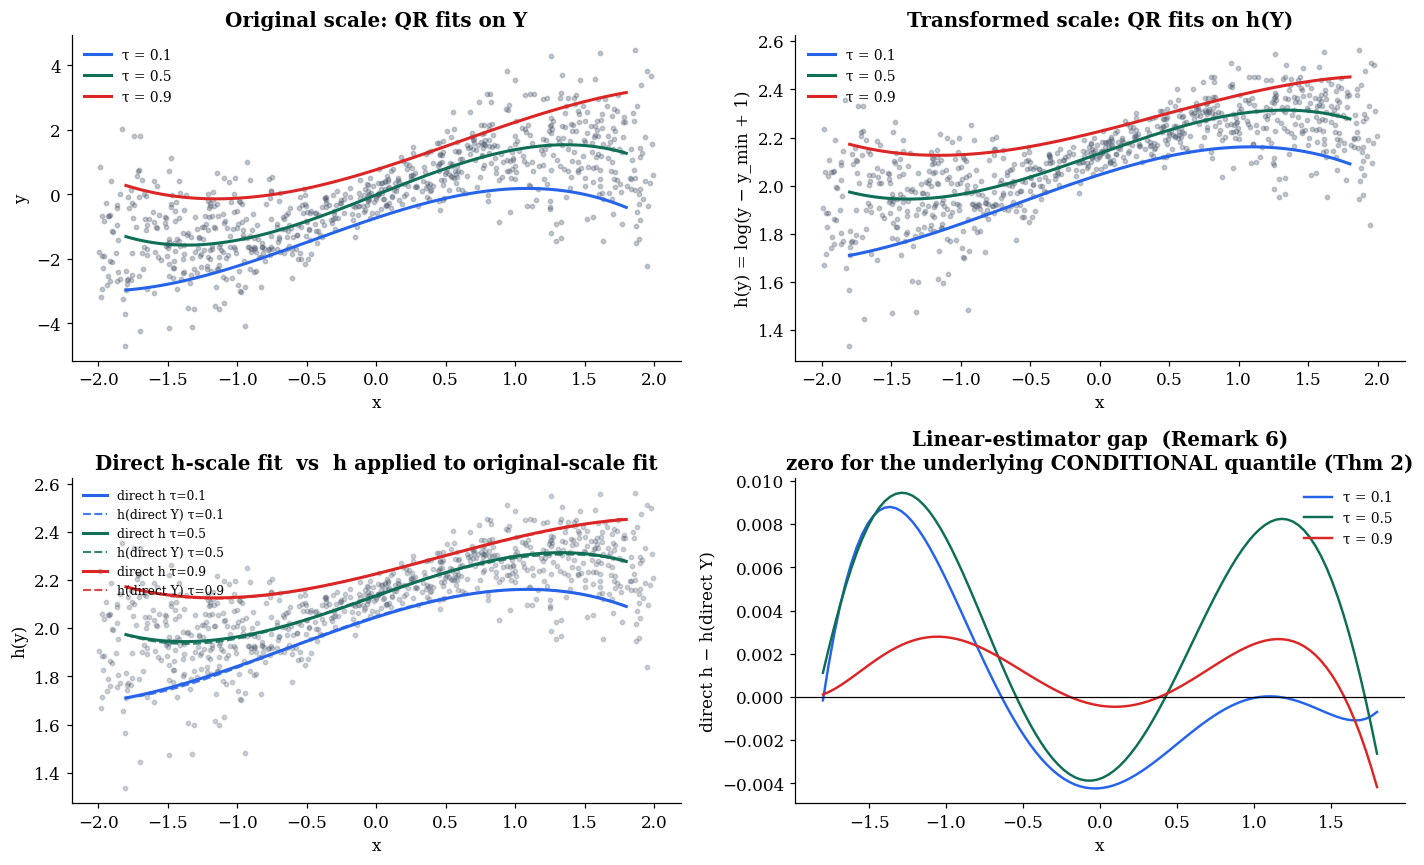


Saved: figures/qr_equivariance.png


In [9]:
# === Equivariance Under Monotone Transformations ===
# Conditional quantiles have a property the conditional mean lacks:
# they commute with monotone transformations of Y. If Y is income and we want
# the median of log(Y), the answer is log of the median of Y — no Jensen
# correction required. This makes quantile regression unusually robust to the
# scale on which the response is modelled.
#
# ──────────────────────────────────────────────────────────────────────────
# Theorem 2 (Equivariance of conditional quantiles).
# Let Y be a random variable with conditional distribution F_{Y|X}, and let
# h: R -> R be a non-decreasing function. Then for every tau in (0, 1) and
# every x in supp(X),
#
#     xi_tau( h(Y) | X = x )  =  h( xi_tau( Y | X = x ) ).
# ──────────────────────────────────────────────────────────────────────────
#
# PROOF. Recall xi_tau(Y | X = x) = inf{ q : F_{Y|X}(q | x) >= tau }. We need
# to express F_{h(Y)|X} in terms of F_{Y|X}. Because h is non-decreasing,
# for any v in R,
#
#     { h(Y) <= v }  =  { Y <= h^{-1}_{+}(v) },
#
# where h^{-1}_{+}(v) := sup{ y : h(y) <= v } is the right-continuous inverse
# (when h is invertible the two coincide; the right-continuous inverse handles
# h with flat regions, and the proof goes through unchanged). Taking
# conditional probabilities,
#
#     F_{h(Y)|X}(v | x)  =  F_{Y|X}( h^{-1}_{+}(v) | x ).
#
# Now compute the conditional tau-quantile of h(Y):
#
#     xi_tau( h(Y) | X = x )
#         = inf{ v : F_{h(Y)|X}(v | x) >= tau }
#         = inf{ v : F_{Y|X}( h^{-1}_{+}(v) | x ) >= tau }
#         = inf{ v : h^{-1}_{+}(v) >= xi_tau(Y | X = x) }    (definition of xi)
#         = h( xi_tau(Y | X = x) ).                                            []
#
# The last step uses non-decreasingness of h: { v : h^{-1}_{+}(v) >= q* } is a
# right half-line in v with infimum h(q*). Strict monotonicity is not needed.
#
# REMARK 6 (What equivariance does NOT say).
# Theorem 2 is a statement about conditional QUANTILES, not about the linear-QR
# ESTIMATOR. If we fit linear QR to Y on features Phi(X) and obtain
# beta-hat(tau), there is no general guarantee that fitting linear QR to h(Y) on
# Phi(X) returns h applied to the original fit at every test point. Two reasons
# the equality fails in finite samples and finite-dimensional feature classes:
#  (i) the linear span of Phi(X) is closed under linear combinations but not
#      under composition with h, so the function class capable of representing
#      xi_tau(h(Y) | X) may differ from the one representing xi_tau(Y | X);
# (ii) even if the function class is the same, the empirical pinball-loss
#      minimiser need not commute with h beyond a constant shift.
# What DOES hold: the underlying conditional quantile FUNCTION is equivariant,
# and well-specified quantile regression captures that equivariance to the
# extent the linear class can represent both functions.
#
# REMARK 7 (Contrast with the conditional mean).
# E[h(Y) | X] equals h(E[Y | X]) only when h is affine, by Jensen's inequality.
# So OLS on log-Y has no clean relationship to OLS on Y; the log-transformation
# changes both the mean function AND the implied error structure. QR's
# equivariance is therefore a strict robustness gain for tasks where the
# response scale is a modelling choice (income, durations, prices, counts).

# Numerical verification. Use the closed-form true conditional quantile under
# the heteroscedastic DGP, transform it through h(y) = log(y - y_min + 1)
# (a strictly monotonic, non-affine function of y), and compare to the true
# conditional quantile of h(Y), computed by transforming a large simulation.

rng_eq = np.random.default_rng(31)
n_pop = 200_000
x_pop, y_pop = synth_heteroscedastic(n_pop, rng_eq)
y_min = y_pop.min()
shift = y_min - 1.0  # subtract this and add 1 to keep positive
def h_transform(y):
    return np.log(y - shift)

z_pop = h_transform(y_pop)  # transformed response

# Estimate xi_tau(h(Y) | X = x) via local-window quantiles of z_pop
def conditional_quantile_window(x_pop, z_pop, x_eval, tau, half_window=0.10):
    """Population-style empirical conditional quantile by binning."""
    out = np.empty_like(x_eval)
    for i, xi in enumerate(x_eval):
        mask = np.abs(x_pop - xi) < half_window
        out[i] = np.quantile(z_pop[mask], tau)
    return out


x_grid_eq = np.linspace(-1.8, 1.8, 25)  # restrict slightly to keep windows full
tau_eq = 0.25
emp_q_h_of_Y = conditional_quantile_window(x_pop, z_pop, x_grid_eq, tau_eq)
true_q_Y = true_conditional_quantile(x_grid_eq, tau_eq)
h_of_true_q = h_transform(true_q_Y)

err = emp_q_h_of_Y - h_of_true_q
print(f'Population check at tau = {tau_eq}:')
print(f'  max | xi_tau(h(Y)|x)  −  h(xi_tau(Y|x)) |  =  {np.max(np.abs(err)):.4f}')
print(f'  mean | ... |                           =  {np.mean(np.abs(err)):.4f}')
print('(small empirical-window error; vanishes as n_pop -> infinity)')

# Also, verify on the LINEAR-QR ESTIMATOR side what Remark 6 warned about:
# the linear QR estimator fit on h(Y) is NOT exactly equal to h applied to the
# linear QR estimator fit on Y, even when the feature class is rich.
rng_est = np.random.default_rng(2024)
n_est = 800
x_est, y_est = synth_heteroscedastic(n_est, rng_est)
z_est = h_transform(y_est)
x_eval_est = np.linspace(-1.8, 1.8, 100)

# Direct: fit QR on z_est at tau = 0.25
qr_direct_h = fit_predict_quantile(x_est, z_est, x_eval_est, 0.25)
# Indirect: fit QR on y_est, then apply h to predictions
qr_y = fit_predict_quantile(x_est, y_est, x_eval_est, 0.25)
qr_indirect_h = h_transform(qr_y)

# Per Theorem 2, the underlying conditional-quantile FUNCTIONS are equal; the
# linear-QR finite-sample estimates differ (Remark 6).
gap = qr_direct_h - qr_indirect_h
print(f'\nLinear-QR estimator gap (Remark 6) at tau = 0.25, n = {n_est}:')
print(f'  max | direct(h)  −  h(direct(Y)) |    =  {np.max(np.abs(gap)):.4f}')
print(f'  mean | ... |                       =  {np.mean(np.abs(gap)):.4f}')
print('(small but nonzero — finite-sample / linear-class artefact, not a violation of Theorem 2.)')

# ─── Figure 4: Equivariance in four panels ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Panel A — original-scale data + QR fits at tau in {0.1, 0.5, 0.9}
ax = axes[0, 0]
ax.scatter(x_est, y_est, s=8, color=SLATE, alpha=0.3)
for tau, c in zip([0.10, 0.50, 0.90], [BLUE, TEAL, RED]):
    qr_orig = fit_predict_quantile(x_est, y_est, x_eval_est, tau)
    ax.plot(x_eval_est, qr_orig, color=c, lw=2.0, label=f'τ = {tau}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Original scale: QR fits on Y')
ax.legend(frameon=False, loc='upper left', fontsize=9)

# Panel B — transformed-scale data + QR fits on h(Y)
ax = axes[0, 1]
ax.scatter(x_est, z_est, s=8, color=SLATE, alpha=0.3)
for tau, c in zip([0.10, 0.50, 0.90], [BLUE, TEAL, RED]):
    qr_h_direct = fit_predict_quantile(x_est, z_est, x_eval_est, tau)
    ax.plot(x_eval_est, qr_h_direct, color=c, lw=2.0, label=f'τ = {tau}')
ax.set_xlabel('x')
ax.set_ylabel('h(y) = log(y − y_min + 1)')
ax.set_title('Transformed scale: QR fits on h(Y)')
ax.legend(frameon=False, loc='upper left', fontsize=9)

# Panel C — overlay h applied to original-scale fits with the direct h-scale fits
ax = axes[1, 0]
ax.scatter(x_est, z_est, s=8, color=SLATE, alpha=0.25)
for tau, c in zip([0.10, 0.50, 0.90], [BLUE, TEAL, RED]):
    qr_orig = fit_predict_quantile(x_est, y_est, x_eval_est, tau)
    qr_via_h = h_transform(qr_orig)
    qr_h_direct = fit_predict_quantile(x_est, z_est, x_eval_est, tau)
    ax.plot(x_eval_est, qr_h_direct, color=c, lw=2.0, label=f'direct h τ={tau}')
    ax.plot(x_eval_est, qr_via_h, color=c, lw=1.4, ls='--', alpha=0.85,
            label=f'h(direct Y) τ={tau}')
ax.set_xlabel('x')
ax.set_ylabel('h(y)')
ax.set_title('Direct h-scale fit  vs  h applied to original-scale fit')
ax.legend(frameon=False, loc='upper left', fontsize=8)

# Panel D — gap (Remark 6)
ax = axes[1, 1]
for tau, c in zip([0.10, 0.50, 0.90], [BLUE, TEAL, RED]):
    qr_orig = fit_predict_quantile(x_est, y_est, x_eval_est, tau)
    qr_via_h = h_transform(qr_orig)
    qr_h_direct = fit_predict_quantile(x_est, z_est, x_eval_est, tau)
    gap_tau = qr_h_direct - qr_via_h
    ax.plot(x_eval_est, gap_tau, color=c, lw=1.6, label=f'τ = {tau}')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('x')
ax.set_ylabel('direct h − h(direct Y)')
ax.set_title('Linear-estimator gap  (Remark 6)\nzero for the underlying CONDITIONAL quantile (Thm 2)')
ax.legend(frameon=False, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/qr_equivariance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {FIG_DIR}/qr_equivariance.png')


---

Bootstrap study: B = 200 resamples per panel.
     n    tau    empirical std (β₁)      ratio · √n
--------------------------------------------------------
   100   0.50                0.3075           3.075
   100   0.90                0.4554           4.554
   500   0.50                0.0903           2.019
   500   0.90                0.1418           3.172

Consistency check (emp_std · √n should stabilise as n grows, AT FIXED tau):
  τ = 0.5:   n = 100 → 3.075,  n = 500 → 2.019
  τ = 0.9:   n = 100 → 4.554,  n = 500 → 3.172
Across τ, the larger value at τ = 0.9 is Remark 8's tail-inflation — D(τ) shrinks as τ → 0 or 1.


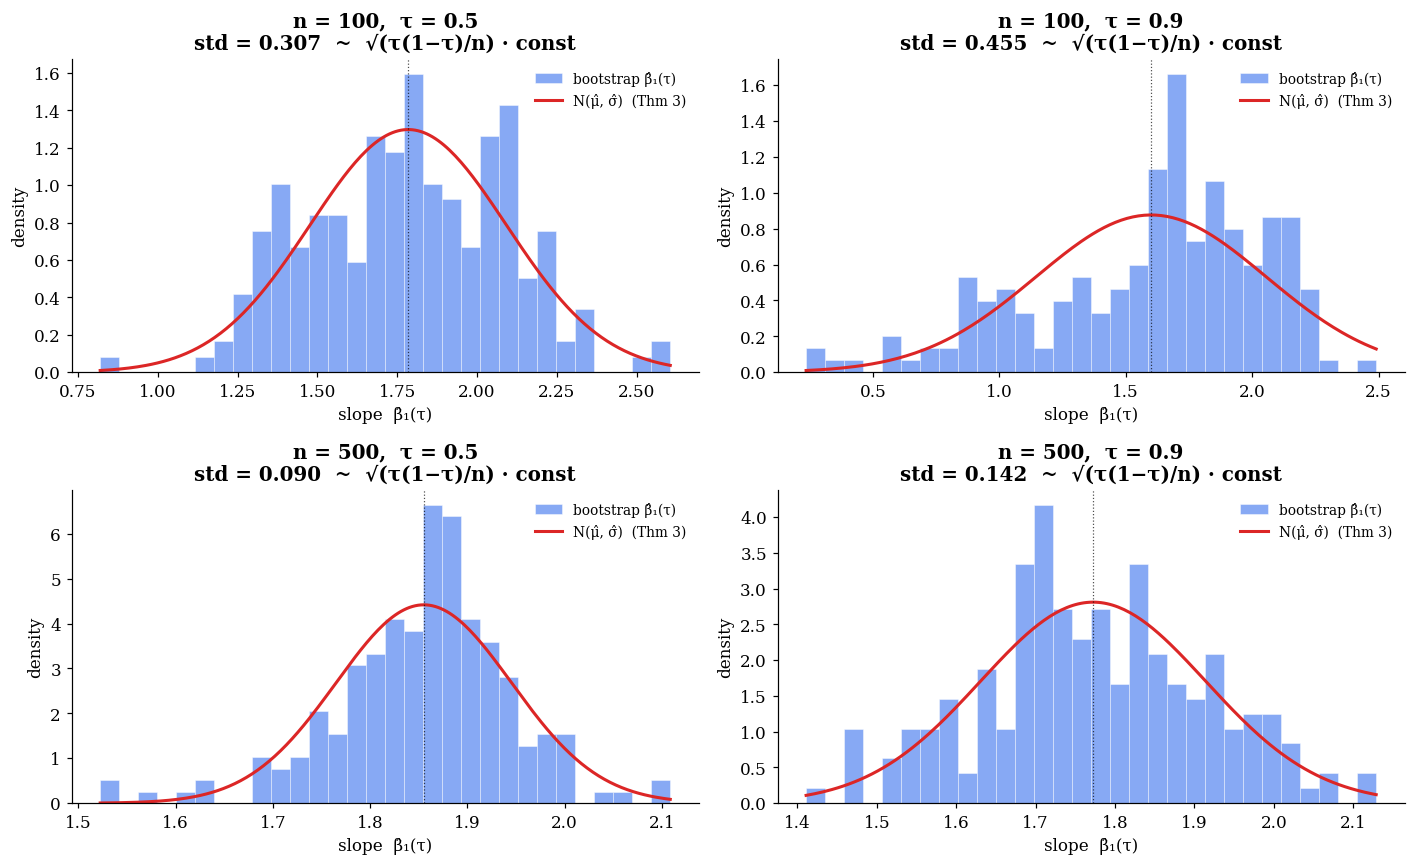


Saved: figures/qr_asymptotic_normality.png


In [10]:
# === Asymptotic Theory: Koenker-Bassett 1978, Knight 1998 ===
# We just saw that QR returns the conditional tau-quantile in expectation. The
# next question is: at what RATE does the estimator converge, and what is the
# limit distribution? The answer, established by Koenker-Bassett 1978 with the
# clean modern proof due to Knight 1998, is the same root-n / Gaussian shape
# we know from OLS, with two structural differences. The "noise variance" is
# replaced by tau(1 - tau) — the Bernoulli variance of the indicator
# 1{Y < q-hat(x)} — and the design Gram matrix is sandwich-replaced by a
# DENSITY-WEIGHTED Gram matrix evaluated at the conditional quantile.
#
# ──────────────────────────────────────────────────────────────────────────
# Theorem 3 (Asymptotic normality of QR — Koenker-Bassett 1978, Knight 1998).
# Suppose (X_i, Y_i) are i.i.d. with finite second moments E[||X||^2] < infinity,
# the conditional density f_{Y|X}(y | x) is continuous and strictly positive
# at y = xi_tau(Y | X = x) for almost every x, and the matrices
#
#     Omega  = E[ X X^T ],
#     D(tau) = E[ f_{Y|X}( xi_tau(Y|X) | X ) * X X^T ]
#
# are positive definite. Then
#
#     sqrt(n) ( beta-hat(tau) - beta(tau) )
#         --d-->   N( 0,  tau (1 - tau) * D(tau)^{-1} Omega D(tau)^{-1} ).
# ──────────────────────────────────────────────────────────────────────────
#
# PROOF SKETCH. Set u_i = Y_i - X_i^T beta(tau) and write the perturbed
# objective Z_n(delta) = sum_i [ rho_tau(u_i - X_i^T delta / sqrt(n)) - rho_tau(u_i) ].
# Knight\'s identity gives the algebraic decomposition
#
#     rho_tau(u - v) - rho_tau(u)
#         = -v * (tau - 1{u < 0}) + integral_0^v ( 1{u <= s} - 1{u <= 0} ) ds.
#
# Apply this with v = X_i^T delta / sqrt(n). The first piece is a sum of mean-zero
# random variables (because E[ tau - 1{u_i < 0} | X_i ] = 0 at the population
# tau-quantile); by the standard CLT it converges to a Gaussian linear in delta
# with covariance tau(1 - tau) * Omega. The second piece is an empirical-process
# integral that, after rescaling, converges to a deterministic quadratic
# (1/2) * delta^T D(tau) delta — the density-weighted matrix arising from a
# first-order expansion of F_{Y|X} at the conditional quantile. Adding the two
# limits, the rescaled objective Z_n converges to a quadratic + linear function
# of delta whose argmin is delta_* = D(tau)^{-1} W, with W ~ N(0, tau(1-tau) Omega).
# Continuous mapping (the argmin lemma for stochastic processes) transfers
# convergence to delta-hat = sqrt(n) (beta-hat(tau) - beta(tau)), giving
# delta-hat --d--> N(0, tau(1-tau) D(tau)^{-1} Omega D(tau)^{-1}). For full
# regularity conditions and the empirical-process step, see formalstatistics
# Topic 32 (Empirical Processes).                                            []
#
# REMARK 8 (The Bernoulli variance factor tau(1 - tau)).
# The asymptotic variance scales with tau(1 - tau), peaking at 0.5 (median) and
# vanishing at the extremes 0 and 1. Geometrically: at the median, the
# indicator 1{Y < q-hat(X)} is a fair coin, contributing maximal variance to
# the estimating equation. At extreme tau, the indicator is nearly constant,
# but D(tau) — the density at the quantile — also goes to zero in the tail,
# which generally pushes the variance UP. The two effects together are why
# extreme-quantile QR estimates have notoriously wide CIs even at moderate n,
# and motivate Extreme Value Theory (T4 Topic 4) as a separate framework for
# the tail regime.
#
# REMARK 9 (Bahadur representation at covariate values).
# A finer statement, due to Bahadur 1966 in the no-covariate case and extended
# to QR in Koenker-Bassett 1978, gives the linearised expansion at any fixed
# x_0:
#
#     sqrt(n) ( q-hat_tau(x_0) - q_tau(x_0) )
#         =  x_0^T D(tau)^{-1} * n^{-1/2} sum_i X_i ( tau - 1{Y_i <= X_i^T beta(tau)} )
#            + o_P(1).
#
# This identifies the asymptotic variance of the conditional-quantile estimator
# at any specific test point x_0 as x_0^T V x_0 where V is the variance from
# Theorem 3. This is what we visualise below: the bootstrap distribution of
# beta-hat(tau)\'s slope coefficient, which is also the prediction\'s slope
# at any fixed x_0 in this 1D-feature setup.

# ─── Numerical demonstration: bootstrap the slope coefficient at varying
# (n, tau) and compare to the asymptotic Gaussian ────────────────────────
def fit_qr_coefs(x_train, y_train, tau, degree=3):
    """Return all polynomial coefficients (incl. intercept) of QR at level tau."""
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Phi = poly.fit_transform(np.asarray(x_train).reshape(-1, 1))
    qr = QuantileRegressor(quantile=tau, alpha=0.0, solver='highs')
    qr.fit(Phi, y_train)
    return np.concatenate([[qr.intercept_], qr.coef_])  # [a0, a1, a2, a3]


def bootstrap_qr_coefs(x, y, tau, B, rng, degree=3):
    """B bootstrap resamples; return (B, p+1) array of coefficient vectors."""
    n = len(x)
    p = degree + 1
    out = np.empty((B, p))
    for b in range(B):
        idx = rng.integers(0, n, n)
        out[b] = fit_qr_coefs(x[idx], y[idx], tau, degree=degree)
    return out


# Run bootstrap at four (n, tau) combinations.
B_boot = 200
combos = [(100, 0.5), (100, 0.9), (500, 0.5), (500, 0.9)]
print(f'Bootstrap study: B = {B_boot} resamples per panel.')
print(f'{"n":>6}  {"tau":>5}  {"empirical std (β₁)":>20}  {"ratio · √n":>14}')
print('-' * 56)
boot_results = {}
rng_boot = np.random.default_rng(2026)
for (n, tau) in combos:
    x_n, y_n = synth_heteroscedastic(n, np.random.default_rng(1000 + n + int(tau*100)))
    coefs_b = bootstrap_qr_coefs(x_n, y_n, tau, B_boot, rng_boot)
    slope = coefs_b[:, 1]  # a1, the linear coefficient (b/c index 0 is intercept)
    emp_std = slope.std(ddof=1)
    boot_results[(n, tau)] = {'coefs': coefs_b, 'slope': slope, 'emp_std': emp_std}
    print(f'{n:>6}  {tau:>5.2f}  {emp_std:>20.4f}  {emp_std * np.sqrt(n):>14.3f}')

# At fixed tau, the asymptotic predicts std(beta-hat) ~ const / sqrt(n), so
# emp_std * sqrt(n) should be roughly constant across n. The constant differs
# ACROSS tau because of the density-weighted D(tau) matrix in Theorem 3 — at
# tau = 0.9 the density at the conditional quantile is smaller (Gaussian tail),
# so D(tau)^{-1} is larger and the asymptotic std is larger. This is
# Remark 8\'s "extreme-tau variance inflation".
print('\nConsistency check (emp_std · √n should stabilise as n grows, AT FIXED tau):')
print(f'  τ = 0.5:   n = 100 → {boot_results[(100, 0.5)]["emp_std"] * 10:.3f},  '
      f'n = 500 → {boot_results[(500, 0.5)]["emp_std"] * np.sqrt(500):.3f}')
print(f'  τ = 0.9:   n = 100 → {boot_results[(100, 0.9)]["emp_std"] * 10:.3f},  '
      f'n = 500 → {boot_results[(500, 0.9)]["emp_std"] * np.sqrt(500):.3f}')
print('Across τ, the larger value at τ = 0.9 is Remark 8\'s tail-inflation — '
      'D(τ) shrinks as τ → 0 or 1.')

# ─── Figure 5: 4-panel bootstrap distributions vs asymptotic normal fit ───
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, (n, tau) in zip(axes.flat, combos):
    r = boot_results[(n, tau)]
    slope = r['slope']
    ax.hist(slope, bins=30, color=BLUE, alpha=0.55, density=True,
            edgecolor='white', linewidth=0.5, label='bootstrap β̂₁(τ)')
    # Overlay the Gaussian with the same mean and std (asymptotic normality)
    grid = np.linspace(slope.min(), slope.max(), 200)
    mu, sd = slope.mean(), slope.std(ddof=1)
    ax.plot(grid, norm.pdf(grid, mu, sd), color=RED, lw=2.0, label='N(μ̂, σ̂)  (Thm 3)')
    ax.axvline(mu, color='black', lw=0.8, ls=':', alpha=0.7)
    ax.set_xlabel('slope  β̂₁(τ)')
    ax.set_ylabel('density')
    ax.set_title(f'n = {n},  τ = {tau}\nstd = {sd:.3f}  ~  √(τ(1−τ)/n) · const')
    ax.legend(frameon=False, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/qr_asymptotic_normality.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {FIG_DIR}/qr_asymptotic_normality.png')


---

Marginal fits at K = 11 levels on n = 120 data:
  evaluation points with crossing:  58 / 200
  total crossing magnitude (sum):    8.4816
After rearrangement:
  evaluation points with crossing:  0 / 200
  total crossing magnitude (sum):    0.0000

L² error to true conditional quantile function:
  marginal:    0.4800
  rearranged:  0.4705  (Remark 11: weakly smaller)


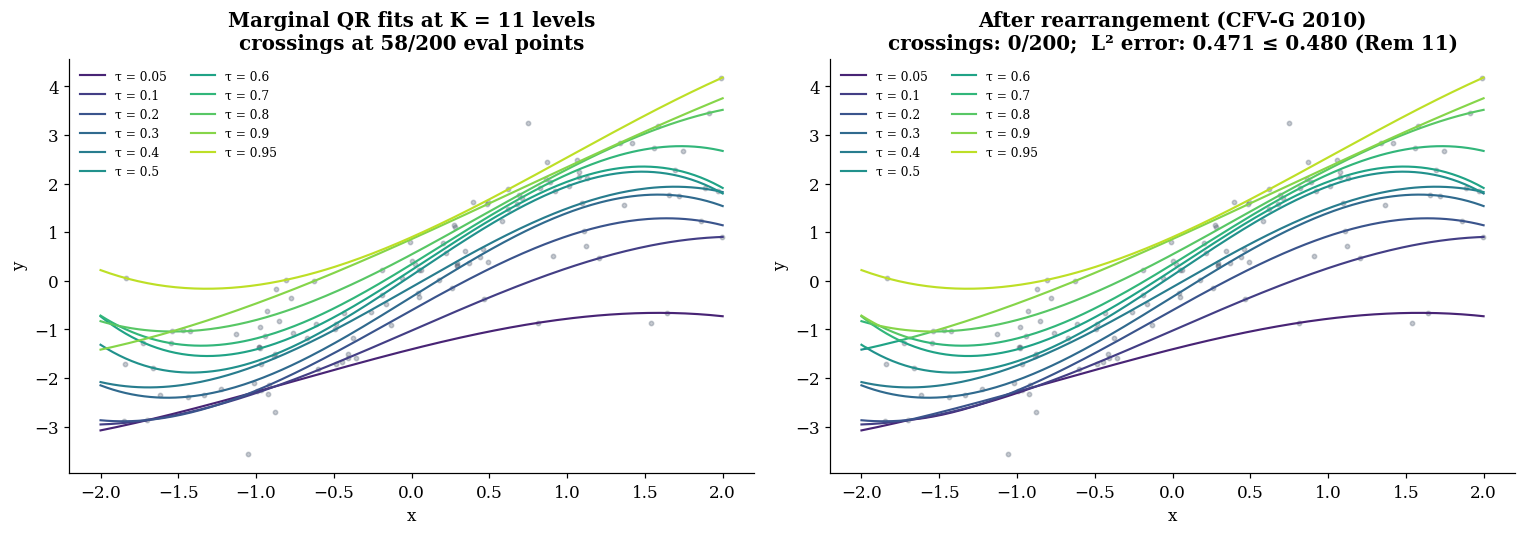


Saved: figures/qr_crossing_rearrangement.png


In [11]:
# === Multi-Quantile Estimation, Crossing, and Rearrangement ===
# A natural use of QR is to fit MULTIPLE quantile levels simultaneously and
# read the resulting bands as a non-parametric estimate of the conditional
# distribution of Y given X. Three or five evenly-spaced quantiles already
# give a usable picture; for high-resolution density estimation, fit at a
# fine grid in (0, 1).
#
# But there is a problem. The population conditional quantiles are weakly
# increasing in tau by definition: xi_{tau1}(Y|X = x) <= xi_{tau2}(Y|X = x)
# whenever tau1 <= tau2. The marginal QR estimates do not enforce this. Each
# tau-fit is a separate optimisation, and at finite n in finite-dimensional
# function classes, the resulting curves can — and frequently do — CROSS:
# the tau = 0.7 fit can dip below the tau = 0.6 fit at some x.
#
# REMARK 10 (Quantile crossing as a coherence violation).
# Crossing is not just an aesthetic flaw. It produces probabilistic
# nonsense: P(Y < q_0.6(x)) > 0.6 and P(Y < q_0.7(x)) < 0.7 cannot both hold
# if q_0.7(x) < q_0.6(x). Any downstream procedure that treats the bands as
# CDF estimates (CQR uses them as prediction-interval endpoints; quantile
# forests use them for distribution prediction) inherits the incoherence.
# Two structural fixes exist:
#  (i) Joint estimation with monotonicity constraints (Bondell-Reich-Wang
#      2010). Augment the LP with linear inequalities q_{tau_k}(x_l) <=
#      q_{tau_{k+1}}(x_l) at a grid of evaluation points; solve a single
#      bigger LP. Pros: exact monotonicity by construction. Cons: scales
#      poorly in n × K × |grid|; loses the per-tau decoupling that makes QR
#      fast and parallelisable.
# (ii) Marginal estimation followed by REARRANGEMENT (Chernozhukov,
#      Fernández-Val & Galichon 2010). Fit each tau independently as before,
#      then at every evaluation point sort the K predicted values along the
#      tau-axis. The rearranged curves are monotone by construction, equal
#      to the originals when no crossing is present, and never worse in L^p
#      for any p >= 1 (CFV-G 2010 Theorem 1). This is the path we take.
#
# ──────────────────────────────────────────────────────────────────────────
# Definition 4 (Rearrangement of conditional-quantile estimates).
# Given a vector of marginal quantile estimates q-hat_{tau_1}(x), ...,
# q-hat_{tau_K}(x) at a fixed test point x and increasing tau-grid
# tau_1 < ... < tau_K, the REARRANGED estimates at x are the sorted values
#
#     q-tilde_{tau_1}(x) <= q-tilde_{tau_2}(x) <= ... <= q-tilde_{tau_K}(x),
#
# i.e., the rearranged estimate at level tau_k equals the (k-th order
# statistic) of {q-hat_{tau_j}(x)}. The function tau -> q-tilde_tau(x) is
# monotone non-decreasing by construction.
# ──────────────────────────────────────────────────────────────────────────
#
# REMARK 11 (Rearrangement weakly improves L^p approximation).
# If the true conditional quantile function tau -> q_tau(x) is monotone (which
# it is, by definition), then for any p >= 1 the L^p distance from the
# rearranged estimates to the truth is no larger than the L^p distance from
# the original marginal estimates. The proof is rearrangement-inequality
# combinatorics: matching a monotone target with a monotone candidate is
# always at least as good as matching a monotone target with a non-monotone
# one. Strict improvement happens whenever crossing is present in the
# original estimates. So rearrangement is a free lunch as a post-processing
# step, never harmful.

def fit_multiple_quantiles(x_train, y_train, x_eval, taus, alpha_l2=0.01, degree=3):
    """Fit QR at each tau in taus on degree-`degree` polynomial features.

    Returns a (len(taus), len(x_eval)) array Q where Q[k, j] = q-hat_{taus[k]}(x_eval[j]).
    """
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Phi_train = poly.fit_transform(np.asarray(x_train).reshape(-1, 1))
    Phi_eval = poly.transform(np.asarray(x_eval).reshape(-1, 1))
    K = len(taus)
    out = np.empty((K, len(x_eval)))
    for k, tau in enumerate(taus):
        qr = QuantileRegressor(quantile=tau, alpha=alpha_l2, solver='highs')
        qr.fit(Phi_train, y_train)
        out[k] = qr.predict(Phi_eval)
    return out


def rearrange_quantile_estimates(Q):
    """CFV-G 2010 rearrangement: sort along the tau-axis at each evaluation point.

    Q has shape (K, N) where K = #quantile levels, N = #evaluation points.
    Returns Q-tilde with the same shape, where Q-tilde[:, j] = sort(Q[:, j]) for each j.
    """
    return np.sort(Q, axis=0)


# Demonstrate. Fit a fine grid of quantile levels on heteroscedastic data and
# look for crossings. We deliberately use a moderate n and a fine tau-grid;
# at large n with smooth DGP, crossings become rare but they remain frequent
# for any practical mid-sized dataset, which is when rearrangement matters.
rng_cross = np.random.default_rng(99)
n_cross = 120
x_cross, y_cross = synth_heteroscedastic(n_cross, rng_cross)
x_eval_cross = np.linspace(-2, 2, 200)
taus_grid = np.array([0.05, 0.10, 0.20, 0.30, 0.40, 0.50,
                      0.60, 0.70, 0.80, 0.90, 0.95])

Q_marginal = fit_multiple_quantiles(x_cross, y_cross, x_eval_cross, taus_grid)
Q_rearranged = rearrange_quantile_estimates(Q_marginal)

# Count crossings: at how many evaluation points is the marginal fit
# non-monotone in tau?
def count_crossing_points(Q):
    """# of evaluation points j such that Q[:, j] is NOT monotone non-decreasing."""
    diffs = np.diff(Q, axis=0)  # shape (K-1, N)
    # any negative diff at column j means crossing at j
    return int(np.sum(np.any(diffs < 0, axis=0)))


def total_crossing_amount(Q):
    """Sum over all (j, k) of max(Q[k, j] - Q[k+1, j], 0) — total crossing magnitude."""
    diffs = np.diff(Q, axis=0)
    return float(np.sum(np.maximum(-diffs, 0)))


n_cross_pts_marg = count_crossing_points(Q_marginal)
amt_marg = total_crossing_amount(Q_marginal)
n_cross_pts_rear = count_crossing_points(Q_rearranged)
amt_rear = total_crossing_amount(Q_rearranged)

print(f'Marginal fits at K = {len(taus_grid)} levels on n = {n_cross} data:')
print(f'  evaluation points with crossing:  {n_cross_pts_marg} / {len(x_eval_cross)}')
print(f'  total crossing magnitude (sum):    {amt_marg:.4f}')
print(f'After rearrangement:')
print(f'  evaluation points with crossing:  {n_cross_pts_rear} / {len(x_eval_cross)}')
print(f'  total crossing magnitude (sum):    {amt_rear:.4f}')

# L^2 approximation error: rearranged should be no worse than marginal.
def l2_error_to_truth(Q, x_eval, taus):
    truths = np.stack([true_conditional_quantile(x_eval, t) for t in taus])  # (K, N)
    return float(np.sqrt(np.mean((Q - truths) ** 2)))


err_marg = l2_error_to_truth(Q_marginal, x_eval_cross, taus_grid)
err_rear = l2_error_to_truth(Q_rearranged, x_eval_cross, taus_grid)
print(f'\nL² error to true conditional quantile function:')
print(f'  marginal:    {err_marg:.4f}')
print(f'  rearranged:  {err_rear:.4f}  (Remark 11: weakly smaller)')
assert err_rear <= err_marg + 1e-9, 'Rearrangement should not increase L² error.'

# ─── Figure 6: Multi-tau fit before/after rearrangement ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(taus_grid)))

# Panel A — marginal fits (with crossings visible)
ax = axes[0]
ax.scatter(x_cross, y_cross, s=8, color=SLATE, alpha=0.3)
for k, tau in enumerate(taus_grid):
    ax.plot(x_eval_cross, Q_marginal[k], color=cmap[k], lw=1.4, label=f'τ = {tau}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Marginal QR fits at K = {len(taus_grid)} levels\n'
             f'crossings at {n_cross_pts_marg}/{len(x_eval_cross)} eval points')
ax.legend(loc='upper left', frameon=False, ncol=2, fontsize=8)

# Panel B — rearranged fits (monotone by construction)
ax = axes[1]
ax.scatter(x_cross, y_cross, s=8, color=SLATE, alpha=0.3)
for k, tau in enumerate(taus_grid):
    ax.plot(x_eval_cross, Q_rearranged[k], color=cmap[k], lw=1.4, label=f'τ = {tau}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'After rearrangement (CFV-G 2010)\n'
             f'crossings: {n_cross_pts_rear}/{len(x_eval_cross)};  '
             f'L² error: {err_rear:.3f} ≤ {err_marg:.3f} (Rem 11)')
ax.legend(loc='upper left', frameon=False, ncol=2, fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/qr_crossing_rearrangement.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {FIG_DIR}/qr_crossing_rearrangement.png')


---

True active indices (s = 5, including intercept): [0, 1, 2, 5, 8]

Solving L1-QR path at tau = 0.5 over 30 lambda values...
  path solved in 0.26s
Running 5-fold CV...
  CV finished in 1.02s

CV-selected lambda: 8.200
Active set at CV-optimum: [0, 1, 2, 5, 8, 17, 18, 20, 26]
True active set:           [0, 1, 2, 5, 8]
  → contains all true active features: True
  → false positives at CV-min:        4
CV-selected lambda typically admits some false positives — Theorem 4 is
about parameter convergence rate, not exact support recovery. The latter
would require post-thresholding or the more conservative BC plug-in lambda.


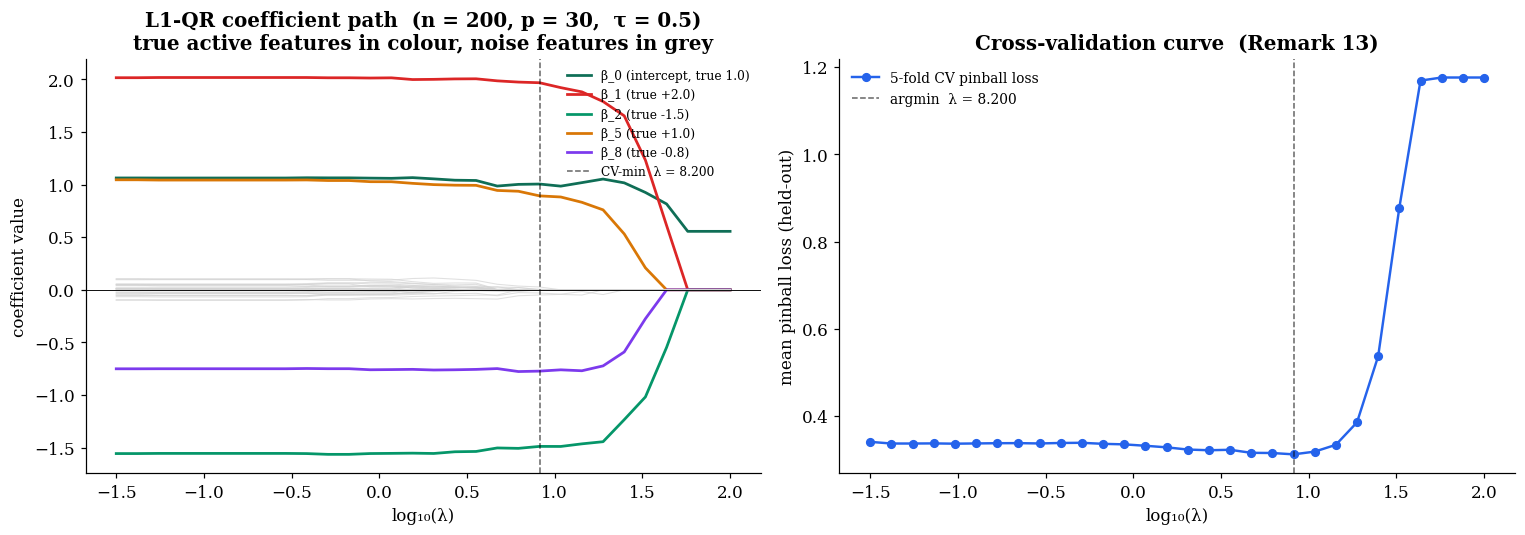


Saved: figures/qr_penalized_path.png


In [12]:
# === Penalized Quantile Regression ===
# Two settings push QR away from its plain Koenker-Bassett 1978 form. First,
# when p > n or p ~ n the unregularised QR LP is under-determined and badly
# behaved. Second, even at moderate p with n large enough for asymptotics, an
# L1 penalty drives variable selection that simple shrinkage cannot match.
# Both settings use the same trick: add a penalty term to the pinball-loss
# objective.
#
# L2 penalty (already familiar from sklearn\'s alpha parameter):
#     min_beta  sum_i rho_tau(Y_i - X_i^T beta) + lambda * ||beta||_2^2.
# This has a closed-form Hessian (modulo the non-smoothness of rho_tau) and
# can be solved either by augmenting the LP with linear-quadratic structure
# or via the smoothed-check-loss accelerated-gradient solver we use in the
# in-browser viz components.
#
# L1 penalty (the focus of this section, "QR-lasso" or "L1-QR"):
#     min_beta  sum_i rho_tau(Y_i - X_i^T beta) + lambda * ||beta||_1.
# This stays a linear program, since ||beta||_1 = 1^T beta^+ + 1^T beta^-
# splits cleanly with beta = beta^+ - beta^-. Augment the QR LP with these
# auxiliary variables and solve for the full path of lambda values.
#
# REMARK 12 (Why L1-QR is the natural high-dim QR).
# At the population level, suppose the true conditional tau-quantile is linear
# with sparse slope vector beta_0(tau) — only s out of p coordinates are
# nonzero. The LP-lasso-QR estimator targets that sparse beta_0(tau) directly.
# By contrast, ridge-QR (L2-penalised) shrinks all coordinates uniformly and
# never sets any to exactly zero, so it cannot recover the sparsity pattern;
# its high-dim rate is correspondingly slower.
#
# ──────────────────────────────────────────────────────────────────────────
# Theorem 4 (Belloni-Chernozhukov 2011 — sketch).
# Suppose (X_i, Y_i) are i.i.d. with X_i bounded, the true conditional
# tau-quantile is q_tau(x) = x^T beta_0(tau) with ||beta_0(tau)||_0 = s, and
# the design satisfies suitable RESTRICTED EIGENVALUE conditions on the
# active subspace. Choose
#
#     lambda  ~  c * sqrt( tau (1 - tau) ) * sqrt( log(p) / n )
#
# for a sufficiently large constant c. Then with high probability,
#
#     || beta-hat(tau) - beta_0(tau) ||_2  =  O_P( sqrt( s log(p) / n ) ),
#
# matching the oracle rate one would obtain with knowledge of the support of
# beta_0(tau).
# ──────────────────────────────────────────────────────────────────────────
#
# PROOF SKETCH. The argument has three pieces, each of which uses tools
# developed in formalstatistics Topic 32 (Empirical Processes).
# (1) GRADIENT-DOMINATION CONDITION. The estimating function for QR has
#     bounded influence (the pinball-loss subgradient is bounded by 1 in
#     absolute value), so a self-normalised concentration inequality gives
#     ||(1/n) sum X_i ( tau - 1{Y_i <= X_i^T beta_0} )||_infinity <= lambda/2
#     with high probability when lambda is chosen as above. This is the
#     "score" condition that ensures the lasso doesn\'t over-shrink.
# (2) RESTRICTED-EIGENVALUE EXCURSION CONTROL. The pinball loss is convex but
#     not strongly convex; restricting to the active cone restores a strong-
#     convexity-like inequality on the design Gram matrix. Combine with the
#     score condition to bound the L^1 deviation in the active subspace.
# (3) ORACLE INEQUALITY. The combined argument yields a high-probability
#     bound of the form ||beta-hat - beta_0||_2^2 <= C * s log(p) / n where
#     C absorbs the restricted-eigenvalue constant and the tau(1 - tau)
#     factor. Square-rooting gives the stated rate.
# Full details in BC2011 §4; the general empirical-process scaffold is
# formalstatistics Topic 32 §32.5.                                          []
#
# REMARK 13 (Choice of lambda).
# The asymptotic rate fixes lambda only up to a constant. In practice, two
# routes pick the constant: (a) the BC2011 self-normalised plug-in, which
# uses a pivotal quantity to set lambda from data without cross-validation;
# (b) cross-validation on the pinball-loss objective itself. We use (b)
# below. CV-based lambda is more familiar and tends to be more aggressive
# than the BC plug-in, which is intentionally conservative for inference.

def solve_lasso_qr_linprog(X, y, tau, lam, no_penalty_mask=None):
    """L1-penalised QR via the standard LP reformulation.

    Variables z = [beta^+ (p), beta^- (p), u^+ (n), u^- (n)].
    Objective: lambda * (1^T beta^+ + 1^T beta^-) + tau * 1^T u^+ + (1-tau) * 1^T u^-,
    with the lambda coefficients zeroed out at indices in no_penalty_mask
    (typically the intercept column).
    Constraints: X (beta^+ - beta^-) + u^+ - u^- = y, all >= 0.
    """
    n, p = X.shape
    if no_penalty_mask is None:
        no_penalty_mask = np.zeros(p, dtype=bool)
    pen_costs = np.where(no_penalty_mask, 0.0, lam)
    c = np.concatenate([
        pen_costs,            # cost on beta^+
        pen_costs,            # cost on beta^-
        tau * np.ones(n),     # cost on u^+
        (1 - tau) * np.ones(n),  # cost on u^-
    ])
    A_eq = np.hstack([X, -X, np.eye(n), -np.eye(n)])
    b_eq = y
    bounds = [(0, None)] * (2 * p + 2 * n)
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    if not res.success:
        raise RuntimeError(f'LP failed at lambda={lam}: {res.message}')
    z = res.x
    beta_pos = z[:p]
    beta_neg = z[p:2 * p]
    return beta_pos - beta_neg


# Synthetic high-dim QR setup.
# n = 200 observations, p = 30 features (1 intercept + 29 standard normals),
# s = 5 truly active features (the intercept + 4 of the 29).
rng_pen = np.random.default_rng(7)
n_pen = 200
p_active = 4   # number of active non-intercept features
p_total_noise = 29
n_features_total = 1 + p_total_noise  # intercept + 29 features

X_raw = rng_pen.standard_normal((n_pen, p_total_noise))
X_pen = np.column_stack([np.ones(n_pen), X_raw])  # design with intercept column
beta_true = np.zeros(n_features_total)
beta_true[0] = 1.0   # intercept
beta_true[1] = 2.0   # active feature 1
beta_true[2] = -1.5  # active feature 2
beta_true[5] = 1.0   # active feature 3
beta_true[8] = -0.8  # active feature 4
active_idx_true = np.where(beta_true != 0)[0]
print(f'True active indices (s = {len(active_idx_true)}, including intercept): {active_idx_true.tolist()}')

# Heteroscedastic noise: depends on the first non-intercept feature
sigma_pen = 0.5 + 0.3 * np.abs(X_pen[:, 1])
y_pen = X_pen @ beta_true + sigma_pen * rng_pen.standard_normal(n_pen)

# Set lambda grid (log-spaced) and solve along the path. The relevant range
# for this DGP is lambda ~ 0.01 to lambda ~ 100, where the unpenalised solution
# (~p active) collapses to the intercept-only solution; the BC2011 lambda is
# somewhere in between.
lambdas = np.logspace(-1.5, 2, 30)
no_pen_mask = np.zeros(n_features_total, dtype=bool)
no_pen_mask[0] = True  # don't penalise intercept

print(f'\nSolving L1-QR path at tau = 0.5 over {len(lambdas)} lambda values...')
import time
t_path0 = time.time()
beta_path = np.empty((len(lambdas), n_features_total))
for k, lam in enumerate(lambdas):
    beta_path[k] = solve_lasso_qr_linprog(X_pen, y_pen, 0.5, lam, no_penalty_mask=no_pen_mask)
print(f'  path solved in {time.time() - t_path0:.2f}s')

# Cross-validation on pinball loss to select lambda
def pinball_loss(y_pred, y_true, tau):
    r = y_true - y_pred
    return np.mean(np.where(r >= 0, tau * r, (tau - 1) * r))


def cv_pinball_for_lambda(X, y, tau, lambdas, n_folds=5, no_penalty_mask=None,
                           rng_cv=None):
    n = X.shape[0]
    if rng_cv is None:
        rng_cv = np.random.default_rng(0)
    perm = rng_cv.permutation(n)
    folds = np.array_split(perm, n_folds)
    losses = np.zeros(len(lambdas))
    for fold_idx in range(n_folds):
        test_idx = folds[fold_idx]
        train_idx = np.concatenate([folds[k] for k in range(n_folds) if k != fold_idx])
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_te, y_te = X[test_idx], y[test_idx]
        for k, lam in enumerate(lambdas):
            beta_k = solve_lasso_qr_linprog(X_tr, y_tr, tau, lam, no_penalty_mask=no_penalty_mask)
            y_pred = X_te @ beta_k
            losses[k] += pinball_loss(y_pred, y_te, tau) / n_folds
    return losses


print('Running 5-fold CV...')
t_cv0 = time.time()
cv_losses = cv_pinball_for_lambda(X_pen, y_pen, 0.5, lambdas, n_folds=5,
                                   no_penalty_mask=no_pen_mask,
                                   rng_cv=np.random.default_rng(123))
print(f'  CV finished in {time.time() - t_cv0:.2f}s')

best_idx = int(np.argmin(cv_losses))
best_lam = lambdas[best_idx]
beta_best = beta_path[best_idx]
active_best = np.where(np.abs(beta_best) > 1e-3)[0]

print(f'\nCV-selected lambda: {best_lam:.3f}')
print(f'Active set at CV-optimum: {active_best.tolist()}')
print(f'True active set:           {active_idx_true.tolist()}')
contains_all_true = set(active_idx_true.tolist()).issubset(set(active_best.tolist()))
n_false_pos = len(active_best) - len(set(active_best) & set(active_idx_true))
print(f'  → contains all true active features: {contains_all_true}')
print(f'  → false positives at CV-min:        {n_false_pos}')
print('CV-selected lambda typically admits some false positives — Theorem 4 is')
print('about parameter convergence rate, not exact support recovery. The latter')
print('would require post-thresholding or the more conservative BC plug-in lambda.')

# ─── Figure 7: L1-QR coefficient path + CV curve ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A — coefficient path
ax = axes[0]
# Highlight true-active coefficients in colour, others in grey
for j in range(n_features_total):
    if j == 0:
        c, lw, lbl = TEAL, 1.8, f'β_0 (intercept, true {beta_true[0]:.1f})'
        ax.plot(np.log10(lambdas), beta_path[:, j], color=c, lw=lw, label=lbl)
    elif beta_true[j] != 0:
        c, lw = [BLUE, RED, GREEN, AMBER, PURPLE][min(np.where(active_idx_true == j)[0][0], 4)], 1.8
        ax.plot(np.log10(lambdas), beta_path[:, j], color=c, lw=lw,
                label=f'β_{j} (true {beta_true[j]:+.1f})')
    else:
        ax.plot(np.log10(lambdas), beta_path[:, j], color='lightgray', lw=0.7, alpha=0.7)
ax.axhline(0, color='black', lw=0.6)
ax.axvline(np.log10(best_lam), color='black', ls='--', lw=1.0, alpha=0.6,
           label=f'CV-min  λ = {best_lam:.3f}')
ax.set_xlabel('log₁₀(λ)')
ax.set_ylabel('coefficient value')
ax.set_title(f'L1-QR coefficient path  (n = {n_pen}, p = {n_features_total},  τ = 0.5)\n'
             f'true active features in colour, noise features in grey')
ax.legend(loc='upper right', frameon=False, fontsize=8)

# Panel B — CV curve
ax = axes[1]
ax.plot(np.log10(lambdas), cv_losses, 'o-', color=BLUE, lw=1.6, ms=5,
        label='5-fold CV pinball loss')
ax.axvline(np.log10(best_lam), color='black', ls='--', lw=1.0, alpha=0.6,
           label=f'argmin  λ = {best_lam:.3f}')
ax.set_xlabel('log₁₀(λ)')
ax.set_ylabel('mean pinball loss (held-out)')
ax.set_title('Cross-validation curve  (Remark 13)')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/qr_penalized_path.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {FIG_DIR}/qr_penalized_path.png')


---

Test-set coverage at target = 1 − α = 0.90, n_test = 500:
  Uncalibrated QR band (τ = 0.05, 0.95):  0.872
  CQR band (with Q̂ = +0.192 correction):              0.918
  Topic 1, Theorem 1 guarantees the CQR band achieves ≥ 1 − α marginally.

Mean band width on evaluation grid:
  Uncalibrated QR:  2.955
  CQR (corrected):  3.339  (shifted by 2 |Q̂| = 0.384)


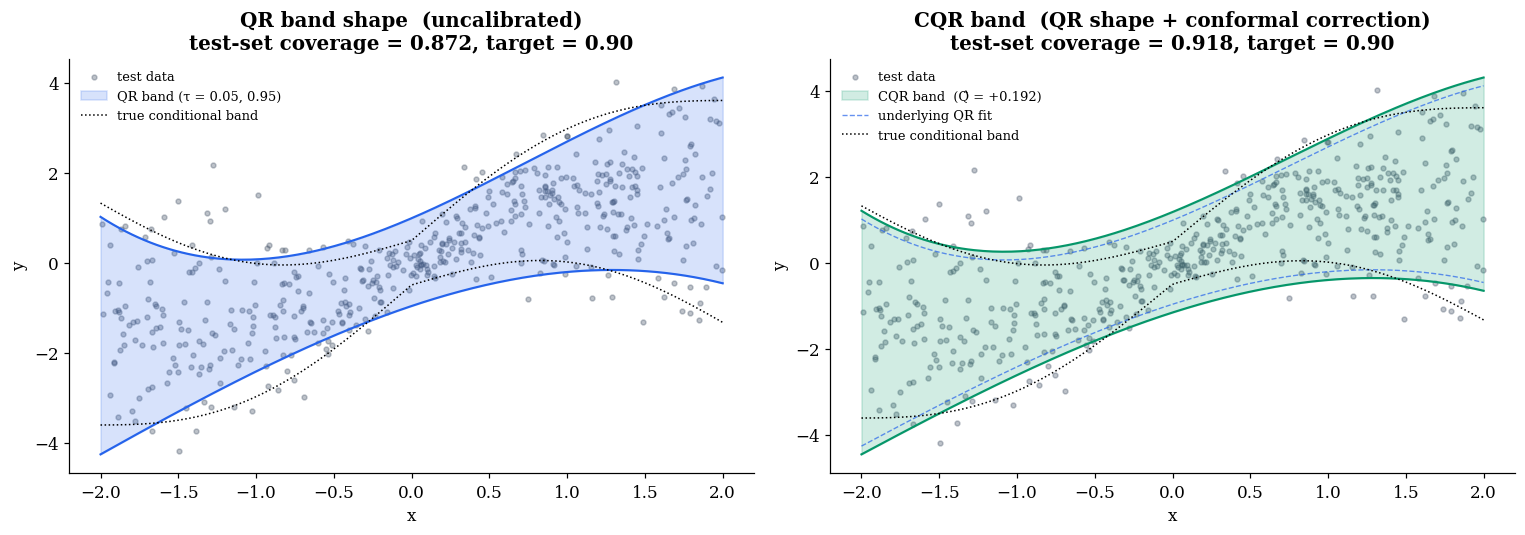


Saved: figures/qr_cqr_callback.png


In [13]:
# === Quantile Regression as the CQR Base Learner ===
# We close the loop with the use that motivated this topic in the T4 track:
# quantile regression as the base learner inside Conformalized Quantile
# Regression (Topic 1, §6). CQR uses two QR fits — at levels alpha/2 and
# 1 - alpha/2 — to produce a heteroscedastic prediction band, and then
# applies conformal calibration on top to guarantee finite-sample marginal
# coverage at level 1 - alpha. Conformal\'s coverage theorem holds for ANY
# base learner (Topic 1, Theorem 1); the role of QR specifically is to give
# the band the right SHAPE.
#
# This is the division of labour:
#   • QR base fits provide the band SHAPE — wide where conditional variance is
#     large, narrow where it is small. A symmetric residual-conformal interval
#     does not have this property; it produces constant-width bands.
#   • Conformal calibration provides the band WIDTH — adjust the QR fits by an
#     additive constant so that the empirical miscoverage rate on a held-out
#     calibration set matches the target alpha.
#
# Topic 1\'s Theorem 1 (split-conformal validity) gives marginal coverage
# 1 - alpha REGARDLESS of how badly QR is misspecified — even constant fits.
# What QR contributes is conditional approximate validity: when the linear
# class spans the true conditional quantile function, the conformal correction
# is a small constant and the resulting band tracks the true conditional
# coverage rate uniformly. When QR is misspecified, the conformal correction
# absorbs the misspecification globally; the resulting band still has marginal
# coverage 1 - alpha but conditional coverage will be uneven. The full
# treatment of prediction-interval procedures — comparing CQR with locally
# adaptive variants (CQR-r, CQR-m), conditional-coverage methods, and base
# learners beyond linear QR — lives in T4 Topic 6 (prediction-intervals,
# coming soon).

# Recall (callback to Topic 1, §6, Definition 4) the CQR prediction set at
# level 1 - alpha based on QR fits q-hat_{alpha/2} and q-hat_{1-alpha/2}:
#
#     C_alpha(x)  =  [ q-hat_{alpha/2}(x) - Q_hat_alpha,
#                      q-hat_{1-alpha/2}(x) + Q_hat_alpha ],
#
# where Q_hat_alpha is the (1 - alpha) empirical quantile (with the standard
# 1/n_cal correction) of the calibration nonconformity scores
#
#     E_i  =  max{ q-hat_{alpha/2}(X_i) - Y_i,  Y_i - q-hat_{1-alpha/2}(X_i) }.
#
# The two QR fits define the band shape; Q_hat_alpha is a single scalar that
# inflates or deflates the band uniformly to hit the target coverage.

def cqr_interval(x_train, y_train, x_cal, y_cal, x_eval, alpha,
                  alpha_l2=0.01, degree=3):
    """CQR prediction interval (Topic 1, §6).

    Returns (lo, hi, Q_hat) where lo, hi are arrays at x_eval and Q_hat is the
    scalar conformal-correction quantile.
    """
    tau_lo = alpha / 2
    tau_hi = 1 - alpha / 2
    # Train QR on the proper training fold
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Phi_tr = poly.fit_transform(x_train.reshape(-1, 1))
    Phi_cal = poly.transform(x_cal.reshape(-1, 1))
    Phi_ev = poly.transform(x_eval.reshape(-1, 1))
    qr_lo = QuantileRegressor(quantile=tau_lo, alpha=alpha_l2, solver='highs').fit(Phi_tr, y_train)
    qr_hi = QuantileRegressor(quantile=tau_hi, alpha=alpha_l2, solver='highs').fit(Phi_tr, y_train)
    # Calibration scores
    pred_lo_cal = qr_lo.predict(Phi_cal)
    pred_hi_cal = qr_hi.predict(Phi_cal)
    E = np.maximum(pred_lo_cal - y_cal, y_cal - pred_hi_cal)
    n_cal = len(y_cal)
    k = int(np.ceil((n_cal + 1) * (1 - alpha)))
    k = min(k, n_cal)  # safety
    Q_hat = np.sort(E)[k - 1]
    # Predict on evaluation grid and apply correction
    pred_lo_ev = qr_lo.predict(Phi_ev)
    pred_hi_ev = qr_hi.predict(Phi_ev)
    return pred_lo_ev - Q_hat, pred_hi_ev + Q_hat, Q_hat


# Demonstrate the QR + conformal decomposition. Generate a fresh
# heteroscedastic dataset, split into proper-train / calibration / test, and
# build a CQR band at alpha = 0.10 (target 90% coverage).
rng_cqr = np.random.default_rng(2027)
n_cqr = 2000
x_cqr_all, y_cqr_all = synth_heteroscedastic(n_cqr, rng_cqr)

# 50% / 25% / 25% split
perm = rng_cqr.permutation(n_cqr)
n_tr = n_cqr // 2
n_cal = n_cqr // 4
idx_tr = perm[:n_tr]
idx_cal = perm[n_tr:n_tr + n_cal]
idx_te = perm[n_tr + n_cal:]
x_tr, y_tr = x_cqr_all[idx_tr], y_cqr_all[idx_tr]
x_cal_arr, y_cal_arr = x_cqr_all[idx_cal], y_cqr_all[idx_cal]
x_te, y_te = x_cqr_all[idx_te], y_cqr_all[idx_te]

alpha_cqr = 0.10
x_eval_cqr = np.linspace(-2, 2, 200)

# Uncalibrated QR band (no conformal correction)
poly_cqr = PolynomialFeatures(degree=3, include_bias=False)
Phi_tr_c = poly_cqr.fit_transform(x_tr.reshape(-1, 1))
Phi_ev_c = poly_cqr.transform(x_eval_cqr.reshape(-1, 1))
Phi_te_c = poly_cqr.transform(x_te.reshape(-1, 1))
qr_lo_only = QuantileRegressor(quantile=alpha_cqr/2, alpha=0.01, solver='highs').fit(Phi_tr_c, y_tr)
qr_hi_only = QuantileRegressor(quantile=1-alpha_cqr/2, alpha=0.01, solver='highs').fit(Phi_tr_c, y_tr)
qr_lo_eval = qr_lo_only.predict(Phi_ev_c)
qr_hi_eval = qr_hi_only.predict(Phi_ev_c)
qr_lo_te = qr_lo_only.predict(Phi_te_c)
qr_hi_te = qr_hi_only.predict(Phi_te_c)

# CQR band (with conformal correction)
cqr_lo, cqr_hi, Q_hat = cqr_interval(x_tr, y_tr, x_cal_arr, y_cal_arr,
                                       x_eval_cqr, alpha_cqr)

# Evaluate on test set
poly_te = PolynomialFeatures(degree=3, include_bias=False).fit(x_tr.reshape(-1, 1))
Phi_te2 = poly_te.transform(x_te.reshape(-1, 1))
cqr_lo_te = qr_lo_only.predict(Phi_te2) - Q_hat
cqr_hi_te = qr_hi_only.predict(Phi_te2) + Q_hat

cov_uncalibrated = float(np.mean((y_te >= qr_lo_te) & (y_te <= qr_hi_te)))
cov_cqr = float(np.mean((y_te >= cqr_lo_te) & (y_te <= cqr_hi_te)))
print(f'Test-set coverage at target = 1 − α = 0.90, n_test = {len(y_te)}:')
print(f'  Uncalibrated QR band (τ = {alpha_cqr/2}, {1-alpha_cqr/2}):  {cov_uncalibrated:.3f}')
print(f'  CQR band (with Q̂ = {Q_hat:+.3f} correction):              {cov_cqr:.3f}')
print(f'  Topic 1, Theorem 1 guarantees the CQR band achieves ≥ 1 − α marginally.')

# Mean band widths
width_uncal = float(np.mean(qr_hi_eval - qr_lo_eval))
width_cqr = float(np.mean(cqr_hi - cqr_lo))
print(f'\nMean band width on evaluation grid:')
print(f'  Uncalibrated QR:  {width_uncal:.3f}')
print(f'  CQR (corrected):  {width_cqr:.3f}  (shifted by 2 |Q̂| = {2*abs(Q_hat):.3f})')

# ─── Figure 8: QR + conformal decomposition ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A — uncalibrated QR band: shape comes from QR
ax = axes[0]
ax.scatter(x_te, y_te, s=10, color=SLATE, alpha=0.35, label='test data')
ax.fill_between(x_eval_cqr, qr_lo_eval, qr_hi_eval, color=BLUE, alpha=0.18,
                 label=f'QR band (τ = {alpha_cqr/2}, {1-alpha_cqr/2})')
ax.plot(x_eval_cqr, qr_lo_eval, color=BLUE, lw=1.4)
ax.plot(x_eval_cqr, qr_hi_eval, color=BLUE, lw=1.4)
true_lo = true_conditional_quantile(x_eval_cqr, alpha_cqr/2)
true_hi = true_conditional_quantile(x_eval_cqr, 1-alpha_cqr/2)
ax.plot(x_eval_cqr, true_lo, color='black', lw=1.0, ls=':', label='true conditional band')
ax.plot(x_eval_cqr, true_hi, color='black', lw=1.0, ls=':')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'QR band shape  (uncalibrated)\ntest-set coverage = {cov_uncalibrated:.3f}, '
             f'target = 0.90')
ax.legend(loc='upper left', frameon=False, fontsize=8.5)

# Panel B — CQR-corrected band: same shape, calibrated width
ax = axes[1]
ax.scatter(x_te, y_te, s=10, color=SLATE, alpha=0.35, label='test data')
ax.fill_between(x_eval_cqr, cqr_lo, cqr_hi, color=GREEN, alpha=0.18,
                 label=f'CQR band  (Q̂ = {Q_hat:+.3f})')
ax.plot(x_eval_cqr, cqr_lo, color=GREEN, lw=1.4)
ax.plot(x_eval_cqr, cqr_hi, color=GREEN, lw=1.4)
ax.plot(x_eval_cqr, qr_lo_eval, color=BLUE, lw=0.9, ls='--', alpha=0.7,
        label='underlying QR fit')
ax.plot(x_eval_cqr, qr_hi_eval, color=BLUE, lw=0.9, ls='--', alpha=0.7)
ax.plot(x_eval_cqr, true_lo, color='black', lw=1.0, ls=':', label='true conditional band')
ax.plot(x_eval_cqr, true_hi, color='black', lw=1.0, ls=':')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'CQR band  (QR shape + conformal correction)\n'
             f'test-set coverage = {cov_cqr:.3f}, target = 0.90')
ax.legend(loc='upper left', frameon=False, fontsize=8.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/qr_cqr_callback.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {FIG_DIR}/qr_cqr_callback.png')


## Connections and Further Reading

**Within formalML, this topic feeds into:**

- **Conformal Prediction (T4 #1).** The two-sided QR fits at $\alpha/2$ and $1 - \alpha/2$ are the base learner inside Conformalized Quantile Regression. Theorem 1 of conformal-prediction guarantees marginal coverage of the CQR band regardless of QR's specification; the role of QR is to give the band the right *shape* — heteroscedastic where the data are heteroscedastic. See §8 of the present notebook.

- **Prediction Intervals (T4 #6, *coming soon*).** A unifying treatment of frequentist prediction intervals — fixed-width residual-based, conformal, and quantile-regression-based — and their coverage guarantees under various assumptions (i.i.d., exchangeable, group-conditional). Quantile regression is one of three "spokes" feeding into that umbrella.

- **Extreme Value Theory (T4 #4, *coming soon*).** Theorem 3's variance formula tells us QR's asymptotic variance inflates as $\tau \to 0$ or $\tau \to 1$, because the density-weighted matrix $D(\tau)$ shrinks in the tail. Beyond moderate quantile levels — typically $\tau$ outside roughly $[0.05, 0.95]$ for a Gaussian-tailed Y — direct QR is not the right framework. EVT replaces it with the generalised Pareto / generalised extreme-value families and a peaks-over-threshold estimator that targets the tail directly.

**Cross-site prerequisites (formalstatistics):**

- **Linear Regression** — the OLS analog. The KB78 estimator is the pinball-loss replacement of squared loss; the LP reformulation is the QR replacement of the normal equations; Theorem 3's asymptotic Gaussian is the QR replacement of OLS's $\hat\beta_{OLS} \sim \mathcal{N}(\beta, \sigma^2 (X^\top X)^{-1})$.

- **Order Statistics and Quantiles** — the no-covariate special case. With a single intercept feature, KB78 reduces to the empirical $\tau$-quantile of $\{Y_i\}$; Theorem 3 reduces to the classical Bahadur-Ghosh asymptotics.

- **Empirical Processes** — the toolkit behind Theorem 3's proof sketch (Knight's identity, the empirical-process limit of the rescaled objective, the argmin lemma) and behind Theorem 4's restricted-eigenvalue / oracle-inequality argument.

**Internal prerequisites (formalML):**

- **Convex Analysis** — the pinball loss is convex but non-smooth; the LP reformulation exploits its piecewise-linear structure.

- **Gradient Descent** — the smoothed-check-loss accelerated-gradient solver is what powers the in-browser visualisation widgets, where running an LP solver in the user's browser is impractical.

---

### References

1. Koenker, R. and Bassett, G. (1978). *Regression quantiles.* Econometrica 46(1): 33–50. The foundational paper.

2. Knight, K. (1998). *Limiting distributions for $L_1$ regression estimators under general conditions.* Annals of Statistics 26(2): 755–770. The clean modern proof of Theorem 3 via the identity in §5.

3. Koenker, R. (2005). *Quantile Regression.* Cambridge University Press. The standard book-length reference.

4. Chernozhukov, V., Fernández-Val, I. and Galichon, A. (2010). *Quantile and probability curves without crossing.* Econometrica 78(3): 1093–1125. The rearrangement result behind §6, Remark 11.

5. Belloni, A. and Chernozhukov, V. (2011). *$\ell_1$-penalized quantile regression in high-dimensional sparse models.* Annals of Statistics 39(1): 82–130. Theorem 4's proof.

6. Bahadur, R. R. (1966). *A note on quantiles in large samples.* Annals of Mathematical Statistics 37(3): 577–580. The original Bahadur representation in the no-covariate case (Remark 9).

7. Romano, Y., Patterson, E. and Candès, E. J. (2019). *Conformalized quantile regression.* NeurIPS. The CQR construction in §8.
